In [1]:
import pandas as pd
import numpy as np
import os
import sys
from trimesh import load_mesh
sys.path.append('/root/capsule/code/beh_ephys_analysis')
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps
from utils.combine_tools import apply_qc, to_str_intlike
import matplotlib.pyplot as plt
import k3d
import json
from matplotlib.colors import LinearSegmentedColormap
# two sample t test
from scipy.stats import ttest_ind
import pickle
%matplotlib inline

In [2]:
data_dir = '/root/capsule/scratch/combined/retro_ccf/manual_proofread_ccf_18brains.csv'
mesh_file = '/root/capsule/code/data_management/new_core_mesh.obj'
retro_ccf = pd.read_csv(data_dir)
save_dir = '/root/capsule/scratch/combined/retro_ccf/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [41]:
from matplotlib.colors import Normalize
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
bregma_pixel = np.array([216, 18, 228])
norm = Normalize(vmin=0, vmax=1)
mesh = load_mesh('/root/capsule/scratch/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj')
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = (mesh_vertices - bregma_pixel)*25/1000
mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
mesh_vertices_mm_old = mesh_vertices_lps
mesh_vertices_mm_flip = mesh_vertices_mm_old.copy()
mesh_vertices_mm_flip[:, ml] = -mesh_vertices_mm_old[:, ml]
mesh_vertices_mm_left = mesh_vertices_mm_old.copy()
mesh_vertices_mm_left[:, ml] = np.abs(mesh_vertices_mm_old[:, ml])
mesh_vertices_mm_old = np.concatenate([mesh_vertices_mm_old, mesh_vertices_mm_flip], axis=0)
# mesh_vertices_mm[:, ml] = -mesh_vertices_mm[:, ml]

In [4]:
import numpy as np
import trimesh


def load_mesh_vertices_baked(mesh_file):
    """
    Load mesh vertices with scene/node transforms applied.

    Returns
    -------
    vertices : (N, 3) ndarray
        Vertex coordinates with transforms baked in.
    faces : (M, 3) ndarray or None
        Faces if available. Not needed for your scatter-style usage.
    """
    obj = trimesh.load(mesh_file, process=False)

    # Case 1: already a single mesh
    if isinstance(obj, trimesh.Trimesh):
        return np.asarray(obj.vertices), np.asarray(obj.faces)

    # Case 2: scene with one or more geometries and transforms
    elif isinstance(obj, trimesh.Scene):
        verts_all = []
        faces_all = []
        v_offset = 0

        for node_name, geom_name in obj.graph.geometry_nodes.items():
            geom = obj.geometry[geom_name].copy()

            # get transform for this node
            T = obj.graph.get(node_name)[0]
            geom.apply_transform(T)

            v = np.asarray(geom.vertices)
            f = np.asarray(geom.faces) if geom.faces is not None else None

            verts_all.append(v)

            if f is not None and len(f) > 0:
                faces_all.append(f + v_offset)

            v_offset += len(v)

        verts = np.concatenate(verts_all, axis=0) if len(verts_all) else np.empty((0, 3))
        faces = np.concatenate(faces_all, axis=0) if len(faces_all) else None
        return verts, faces

    else:
        raise TypeError(f"Unsupported loaded object type: {type(obj)}")

In [5]:
print(mesh_file)

/root/capsule/code/data_management/new_core_mesh.obj


In [17]:
ml, ap, dv = 0, 1, 2
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
mesh_file = '/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj' 
mesh = load_mesh(mesh_file)
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh = load_mesh(mesh_file)
    mesh_vertices = np.array(mesh.vertices)
    mesh_vertices = mesh_vertices
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
    # mesh_vertices_mm_flip = mesh_vertices_mm.copy()
    # mesh_vertices_mm_flip[:, ml] = 5.7*2 - mesh_vertices_mm[:, ml]
    # mesh_vertices_mm = np.concatenate([mesh_vertices_mm, mesh_vertices_mm_flip], axis=0)
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])
# mesh_vertices_mm_left = mesh_vertices_mm.copy()
# mesh_vertices_mm_left[:, ml] = np.abs(mesh_vertices_mm[:, ml])
# mesh_vertices_mm = np.concatenate([mesh_vertices_mm, mesh_vertices_mm_left], axis=0)

In [38]:
# 3D plot of list of mesh vertices
plot = k3d.plot()
mesh_list = os.listdir('/root/capsule/data/LC_percentile_meshes')
mesh_list = [f for f in mesh_list if f.endswith('.obj')]
percentile = [name.split('.')[0].split('_')[-1] for name in mesh_list]
# if number convert to number, if not set to none
def to_float_or_none(x):
    try:
        return float(x)
    except ValueError:
        return None
percentile = [to_float_or_none(p) for p in percentile]

[50.0, 10.0, 90.0, 70.0, 30.0, 60.0, 20.0, 80.0, None, 40.0]

In [46]:

import matplotlib.cm as cm

cmap = cm.get_cmap('coolwarm')
n_mesh = len(mesh_list)

for i, mesh_file in enumerate(mesh_list):

    mesh_file_curr = os.path.join('/root/capsule/data/LC_percentile_meshes', mesh_file)
    mesh_vertices = load_mesh(mesh_file_curr).vertices

    mesh_vertices = mesh_vertices / 1000
    mesh_vertices[:, 2] = -mesh_vertices[:, 2]
    mesh_vertices[:, 0] = -mesh_vertices[:, 0]

    mesh_vertices = mesh_vertices - bregma_LPS_mm
    mesh_vertices[:, ml] = np.abs(mesh_vertices[:, ml])

    # get color for this mesh
    if percentile[i] is not None:
        rgba = cmap(percentile[i] / 100)
        rgb = (np.array(rgba[:3]) * 255).astype(np.uint32)
    else:
        rgb = np.array([128, 128, 128], dtype=np.uint32)

    color_hex = (rgb[0] << 16) + (rgb[1] << 8) + rgb[2]

    colors = np.full(mesh_vertices.shape[0], color_hex, dtype=np.uint32)

    plot += k3d.points(
        positions=mesh_vertices.astype(np.float32),
        colors=colors,
        point_size=0.01,
        opacity=0.1,
        name=mesh_file.split('.')[0]
    )

# mesh_vertices_mm_old
plot += k3d.points(
    positions=mesh_vertices_mm_old.astype(np.float32),
    color=0x000000,  # black color
    point_size=0.01,
    opacity=0.1,
    name='old CCF Mesh'
    
)



plot.display()
# sav
save_path = os.path.join(save_dir, 'lc_percentile_meshes_3d_plot.html')
with open(save_path, 'w') as f:
    f.write(plot.get_snapshot())

/tmp/ipykernel_835259/2350745443.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')
/opt/conda/lib/python3.10/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "float32" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

In [7]:
bregma_pixel_retro = np.array([228, 18, 216])
ccf_neurons_mm = (retro_ccf[['x', 'y', 'z']].values - bregma_pixel_retro) * 25 / 1000  # convert to mm
ccf_neurons_mm[:, [dv, ap]] = ccf_neurons_mm[:, [ap, dv]]  # Mirror ML to left
ccf_neurons_mm[:, dv] = -ccf_neurons_mm[:, dv]  # Mirror ML to left
ccf_neurons_mm[:, ml] = np.abs(ccf_neurons_mm[:, ml])  # Mirror ML to left


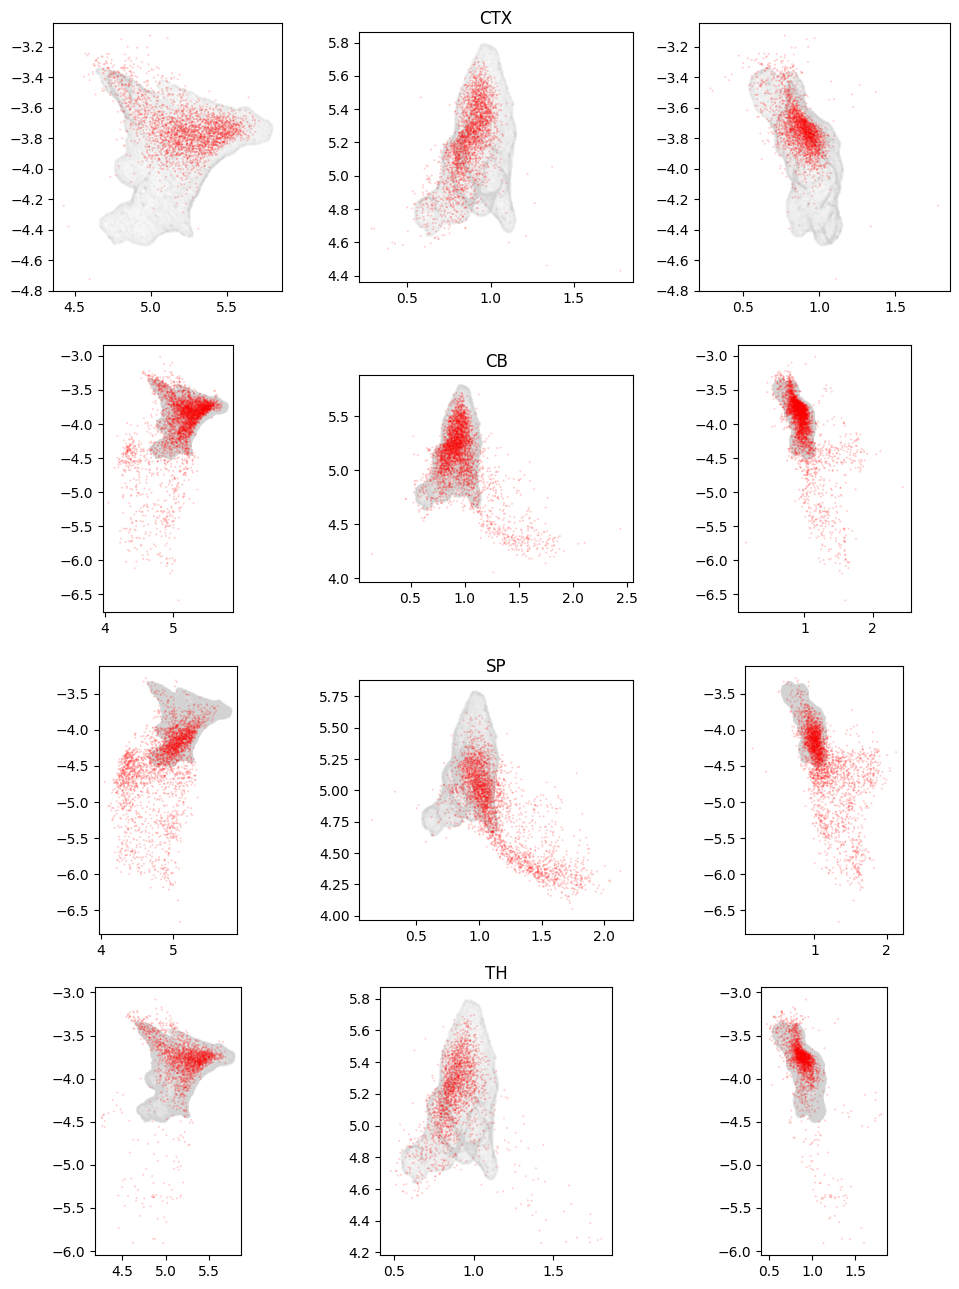

In [8]:
fig = plt.figure(figsize=(12, 4*len(retro_ccf['injection_region'].unique())))
gs = fig.add_gridspec(len(retro_ccf['injection_region'].unique()), 3)
for plane, ax_ind in zip(planes.keys(), range(3)):
    # ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
        mask = (retro_ccf['injection_region'] == tar)
        ax = fig.add_subplot(gs[ind, ax_ind])
        ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
        
        sc = ax.scatter(ccf_neurons_mm[mask, planes[plane][0]], ccf_neurons_mm[mask, planes[plane][1]], color='r', alpha=0.2, s=2, edgecolor='none', label=tar)
        ax.set_aspect(aspect='equal')
        if plane == 'hor':
            ax.set_title(tar)
        # if planes[plane][1] == dv:
        #     # flip
        #     ax.invert_yaxis()
    # ax.set_title(plane)

In [9]:
import numpy as np
import trimesh


def load_mesh_baked(mesh_file):
    obj = trimesh.load(mesh_file, process=False)

    if isinstance(obj, trimesh.Trimesh):
        return np.asarray(obj.vertices), np.asarray(obj.faces)

    elif isinstance(obj, trimesh.Scene):
        verts_all = []
        faces_all = []
        v_offset = 0

        for node_name, geom_name in obj.graph.geometry_nodes.items():
            geom = obj.geometry[geom_name].copy()
            T = obj.graph.get(node_name)[0]
            geom.apply_transform(T)

            v = np.asarray(geom.vertices)
            f = np.asarray(geom.faces)

            verts_all.append(v)
            faces_all.append(f + v_offset)
            v_offset += len(v)

        verts = np.concatenate(verts_all, axis=0)
        faces = np.concatenate(faces_all, axis=0)
        return verts, faces

    else:
        raise TypeError(f"Unsupported type: {type(obj)}")


def get_mesh_vertices_faces_mm(mesh_file, pir_to_lps=None, mirror=False):
    ml, ap, dv = 0, 1, 2

    vertices, faces = load_mesh_baked(mesh_file)

    # if 'scratch' in mesh_file:
    #     vertices = (vertices - np.array([216, 18, 228])) * 25 / 1000
    #     if pir_to_lps is not None:
    #         vertices = pir_to_lps(vertices)
    # else:

    # if mirror:
    #     vertices_flip = vertices.copy()
    #     vertices_flip[:, ml] = 5.7 * 2 - vertices[:, ml]
    #     faces_flip = faces + len(vertices)

    #     vertices = np.concatenate([vertices, vertices_flip], axis=0)
    #     faces = np.concatenate([faces, faces_flip], axis=0)

    return vertices, faces


mesh_vertices_mm, mesh_faces = get_mesh_vertices_faces_mm(
    mesh_file,
    pir_to_lps=pir_to_lps,
    mirror=('scratch' not in mesh_file)
)

mesh_render = trimesh.Trimesh(
    vertices=mesh_vertices_mm,
    faces=mesh_faces,
    process=False
)

# light gray mesh color with some transparency
mesh_render.visual.face_colors = np.tile(
    np.array([200, 200, 200, 2], dtype=np.uint8),
    (len(mesh_faces), 1)
)


points_render = trimesh.points.PointCloud(
    ccf_neurons_mm,
    colors=np.tile(np.array([255, 0, 0, 180], dtype=np.uint8), (len(ccf_neurons_mm), 1))
)
scene.show(point_size=10)
scene = trimesh.Scene([mesh_render, points_render])
scene.show()




NameError: name 'scene' is not defined

In [19]:
# create a filter by within certain distance to the mesh
distance_threshold = 0.2  # in mm
from scipy.spatial import cKDTree
mesh_kd_tree = cKDTree(mesh_vertices_mm)
distances, _ = mesh_kd_tree.query(ccf_neurons_mm, k=1)
close_to_mesh_mask = distances < distance_threshold


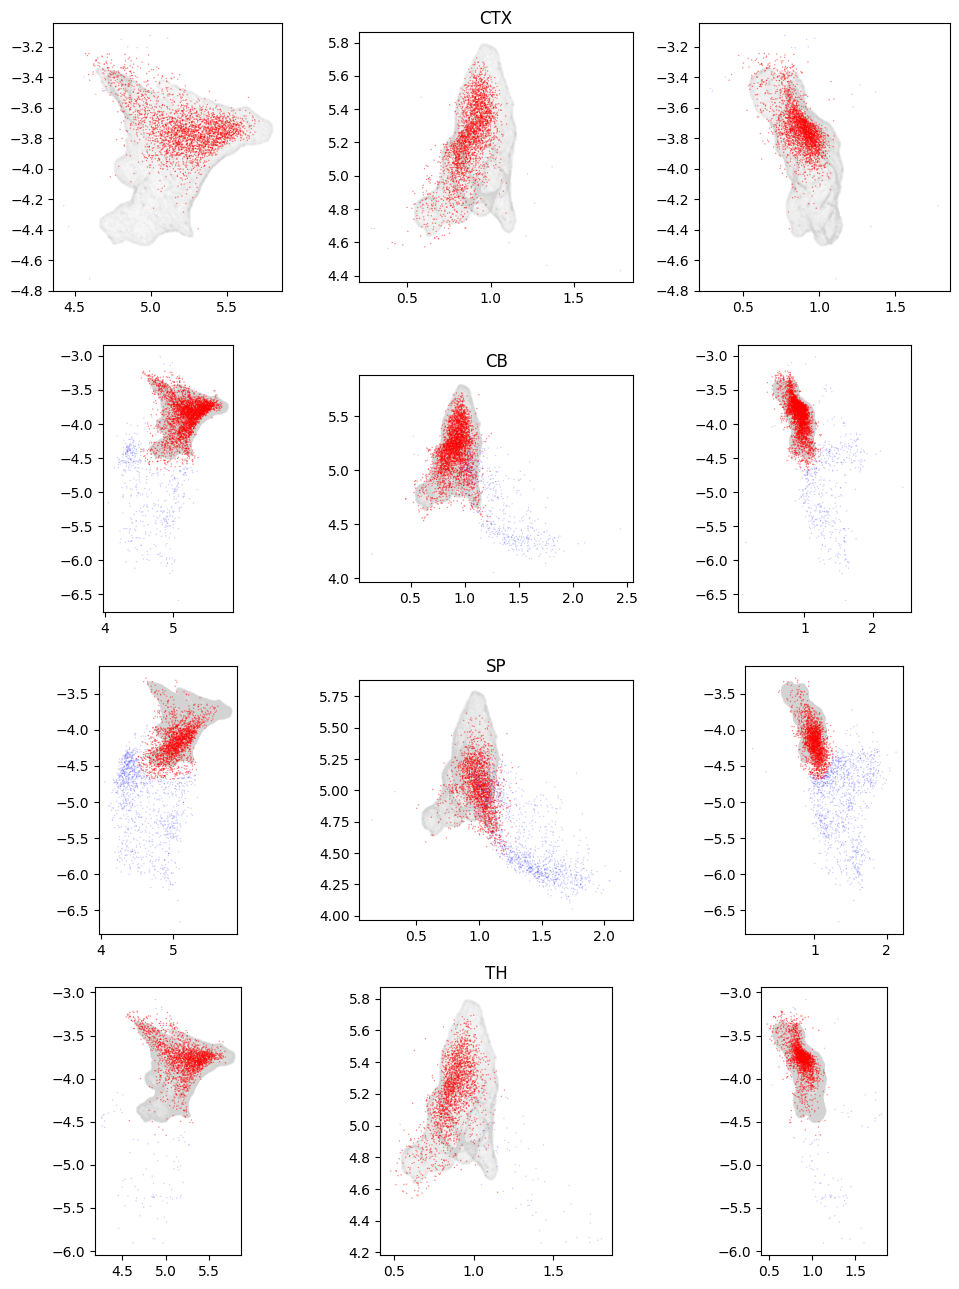

In [20]:
# plot masked and unmasked points
fig = plt.figure(figsize=(12, 4*len(retro_ccf['injection_region'].unique())))
gs = fig.add_gridspec(len(retro_ccf['injection_region'].unique()), 3)
for plane, ax_ind in zip(planes.keys(), range(3)):
    # ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
        mask = (retro_ccf['injection_region'] == tar)
        ax = fig.add_subplot(gs[ind, ax_ind])
        ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
        
        sc = ax.scatter(ccf_neurons_mm[mask & close_to_mesh_mask, planes[plane][0]], ccf_neurons_mm[mask & close_to_mesh_mask, planes[plane][1]], color='r', alpha=0.5, s=1, edgecolor='none', label=tar)
        sc2 = ax.scatter(ccf_neurons_mm[mask & ~close_to_mesh_mask, planes[plane][0]], ccf_neurons_mm[mask & ~close_to_mesh_mask, planes[plane][1]], color='b', alpha=0.2, s=1, edgecolor='none', label=tar)
        ax.set_aspect(aspect='equal')
        if plane == 'hor':
            ax.set_title(tar)
    # ax.set_title(plane)
plt.show()

In [21]:
# plot in 3d space using k3d
plot = k3d.plot()
# transparent gray mesh
plot += k3d.points(mesh_vertices_mm.astype(np.float32), point_size=0.001, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
# plot neurons projecting to each region in different colors
colors = [0xFF0000, 0x00FF00, 0x0000FF, 0xFFFF00, 0x00FFFF, 0xFF00FF, 0x880000, 0x008800, 0x000088]
for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
    mask = (retro_ccf['injection_region'] == tar)
    plot += k3d.points(ccf_neurons_mm[mask&close_to_mesh_mask].astype(np.float32), point_size=0.03, shader='flat', color=colors[ind % len(colors)], name=tar, opacity=0.5)
plot.display()

Output()

In [ ]:
# # # Step 1: Extract the relevant data
# # coordinates = df_ipsi[['RC', 'DV', 'ML']].values
# projection_regions = retro_ccf['injection_region'].values
# filter = (projection_regions!="TH") & (ccf_neurons_mm[:, dv_mesh] <= 4.8) & (projection_regions != 'CB')
# # # Step 2: Perform PCA
# # pca = PCA(n_components=3)
# # pca_result = pca.fit_transform(coordinates)
# from sklearn.decomposition import PCA
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# # Step 3: Perform LDA on the PCA result
# lda = LinearDiscriminantAnalysis(n_components=1)
# lda_result = lda.fit_transform(ccf_neurons_mm[filter], projection_regions[filter])

In [ ]:
# # change projection regions to numbers
# projection_regions_num = np.zeros_like(projection_regions)
# for i, region in enumerate(np.unique(projection_regions)):
#     projection_regions_num[projection_regions == region] = i

In [ ]:
# plt.figure()
# plt.scatter(lda_result[:, 0], lda_result[:, 1], c=projection_regions_num[filter], cmap='viridis', alpha=0.5, s = 5)
# # plt histogram of projection regions along the first LDA axis
# plt.figure()
# for i, region in enumerate(np.unique(projection_regions)):
#     plt.hist(lda_result[projection_regions_num[filter] == i, 0], bins=50, alpha=0.5, label=region, density=True)
# plt.legend()

# Compare unit location between retro data vs recording data

## Compare dorsal edge

In [22]:
# plot dorsal_edge of LC labeled by hand
txt_file = "/root/capsule/code/data_management/animal_ids.txt"

with open(txt_file) as f:
    animal_ids = [line.strip() for line in f if line.strip()]

In [23]:
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree
distance_threshold = 0.15
kernel="linear"
smoothing = 0.2
epsilon = 0.5 
concat_dorsal_edge = []
concat_dorsal_surface_L = []
concat_dorsal_surface_R = []
for animal_id in animal_ids:
    dorsal_edge_json = f'/root/capsule/data/dorsal_edges/{animal_id}_dorsal_edge_ccf_fix.json'
    if os.path.exists(dorsal_edge_json):
        with open(dorsal_edge_json, 'r') as f:
            dorsal_edge_dict = json.load(f)
        # make into a dataframe
        dorsal_edge_df = pd.DataFrame(dorsal_edge_dict['xyz_picks'], columns=['x', 'y', 'z'])
        # make into a dataframe
        dorsal_edge_mat = dorsal_edge_df.values
        dorsal_edge_mat[:, 0] = dorsal_edge_mat[:, 0]
        # dorsal_edge_mat[:, ml]  = np.abs(dorsal_edge_mat[:, ml])
        concat_dorsal_edge.append(dorsal_edge_mat)

        dorsal_edge_L = dorsal_edge_mat[dorsal_edge_mat[:, ml]>0]
        dorsal_edge_R = dorsal_edge_mat[dorsal_edge_mat[:, ml]<0]

        # infer a plain surface from the dorsal edge points using smoothing spline

        X_L = dorsal_edge_L[:, [ap, dv]]
        y_L = dorsal_edge_L[:, ml]

        rbf_L = RBFInterpolator(
            X_L, y_L,
            kernel=kernel,   # often nicer than "linear"
            smoothing=smoothing,                # 0 == interpolate exactly
            neighbors=10,            # tune: 20–100 typical
            epsilon=epsilon
        )

        X_R = dorsal_edge_R[:, [ap, dv]]
        y_R = dorsal_edge_R[:, ml]
        rbf_R = RBFInterpolator(
            X_R, y_R,
            kernel=kernel,
            smoothing=smoothing,
            neighbors=10,
            epsilon=epsilon
        )
        ap_grid = np.linspace(np.min(dorsal_edge_mat[:, ap]), np.max(dorsal_edge_mat[:, ap]), 50)
        dv_grid = np.linspace(np.min(dorsal_edge_mat[:, dv]), np.max(dorsal_edge_mat[:, dv]), 50)
        AP, DV = np.meshgrid(ap_grid, dv_grid)
        # get rid of points too far from the dorsal edge points, 0.2 mm away
        dorsal_edge_kd_tree_L = cKDTree(dorsal_edge_L[:, [ap, dv]])
        dorsal_edge_kd_tree_R = cKDTree(dorsal_edge_R[:, [ap, dv]])
        query_pts_all = np.column_stack([AP.ravel(), DV.ravel()])
        distances_L, _ = dorsal_edge_kd_tree_L.query(query_pts_all, k=1)
        distances_R, _ = dorsal_edge_kd_tree_R.query(query_pts_all, k=1)
        
        mask_L = distances_L < distance_threshold
        mask_R = distances_R < distance_threshold

        query_pts = np.column_stack([AP.ravel(), DV.ravel()])
        # evaluate
        ML_L = rbf_L(query_pts[mask_L])
        ML_R = rbf_R(query_pts[mask_R])
        
        dorsal_surface_L = np.vstack([ML_L, AP.ravel()[mask_L], DV.ravel()[mask_L]]).T
        dorsal_surface_R = np.vstack([ML_R, AP.ravel()[mask_R], DV.ravel()[mask_R]]).T
        
        concat_dorsal_surface_L.append(dorsal_surface_L)
        concat_dorsal_surface_R.append(dorsal_surface_R)

dorsal_edge_ccfs = np.vstack(concat_dorsal_edge)
dorsal_edge_ccfs_right = dorsal_edge_ccfs[dorsal_edge_ccfs[:, ml]<0]
dorsal_edge_ccfs_right[:, ml] = -dorsal_edge_ccfs_right[:, ml]
dorsal_edge_ccfs_left = dorsal_edge_ccfs[dorsal_edge_ccfs[:, ml]>0]

In [24]:
# plot dorsal edge points and surfaces together one by one and save
for i in range(len(concat_dorsal_surface_L)):
    plot = k3d.plot()
    # transparent gray mesh
    plot += k3d.points(mesh_vertices_lps.astype(np.float32), point_size=0.01, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
    plot += k3d.points(mesh_vertices_mm_flip.astype(np.float32), point_size=0.01, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh Flip')
    # plot dorsal edge points 
    plot += k3d.points(concat_dorsal_edge[i].astype(np.float32), point_size=0.02, shader='flat', color=0x00FF00, name='Dorsal Edge', opacity=0.8)
    dorsal_surface_L = concat_dorsal_surface_L[i]
    dorsal_surface_R = concat_dorsal_surface_R[i]
    plot += k3d.points(dorsal_surface_L.astype(np.float32), point_size=0.01, shader='flat', color=0x0000FF, name='Dorsal Surface L', opacity=0.5)
    plot += k3d.points(dorsal_surface_R.astype(np.float32), point_size=0.01, shader='flat', color=0xFF0000, name='Dorsal Surface R', opacity=0.5)
    # save to html
    save_file = os.path.join('/root/capsule/scratch/combined/ccf_maps/dorsal_surface/', f'{str(animal_ids[i])}.html')
    with open(save_file, 'w') as f:
        f.write(plot.get_snapshot())

In [25]:
# plt dorsal_edge, retro points and mesh in 3d
plot = k3d.plot()
# transparent gray mesh
plot += k3d.points(mesh_vertices_mm.astype(np.float32), point_size=0.001, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
# plot dorsal edge points
plot += k3d.points(dorsal_edge_ccfs.astype(np.float32), point_size=0.01, shader='flat', color=0x0000FF, name='Dorsal Edge', opacity=0.8)
# plot retro ccf points
plot += k3d.points(ccf_neurons_mm[close_to_mesh_mask].astype(np.float32), point_size=0.01, shader='flat', color=0xFF0000, name='Retro CCF', opacity=0.5)
plot.display()

Output()

In [27]:

# plt dorsal_edge, retro points and mesh in 3d
plot = k3d.plot()
# transparent gray mesh
plot += k3d.points(mesh_vertices_lps.astype(np.float32), point_size=0.01, shader='flat', color=0x4DA6FF, opacity=0.1, name='CCF Mesh')
# transparent gray mesh
plot += k3d.points(mesh_vertices_mm.astype(np.float32), point_size=0.01, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
# plot dorsal edge points 
plot += k3d.points(dorsal_edge_ccfs_left.astype(np.float32), point_size=0.01, shader='flat', color=0x0000FF, name='Dorsal Edge', opacity=0.8)
plot += k3d.points(dorsal_edge_ccfs_right.astype(np.float32), point_size=0.01, shader='flat', color=0xFF0000, name='Dorsal Edge', opacity=0.8)
plot.display()

Output()

In [29]:
# plot all dorsal surface points
dorsal_surface_ccfs_L = np.vstack(concat_dorsal_surface_L)
dorsal_surface_ccfs_R = np.vstack(concat_dorsal_surface_R)
dorsal_surface_ccfs_R[:, ml] = -dorsal_surface_ccfs_R[:, ml]
plot = k3d.plot()
# transparent gray mesh
plot += k3d.points(mesh_vertices_lps.astype(np.float32), point_size=0.01, shader='flat', color=0x4DA6FF, opacity=0.1, name='CCF Mesh')
plot += k3d.points(mesh_vertices_mm.astype(np.float32), point_size=0.01, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
# plot dorsal edge points
plot += k3d.points(dorsal_surface_ccfs_L.astype(np.float32), point_size=0.001, shader='flat', color=0x0000FF, name='Dorsal Surface L', opacity=0.5)
plot += k3d.points(dorsal_surface_ccfs_R.astype(np.float32), point_size=0.001, shader='flat', color=0xFF0000, name='Dorsal Surface R', opacity=0.5)
plot.display()
# save dorsal surface points


Output()

Normal vector of dorsal edge plane: [0.87884946 0.03994857 0.47542375]


Text(0.5, 1.0, 'Dorsal Edge Projections onto Normal Vector\nVariance Left: 0.0598, Right: 0.0585')

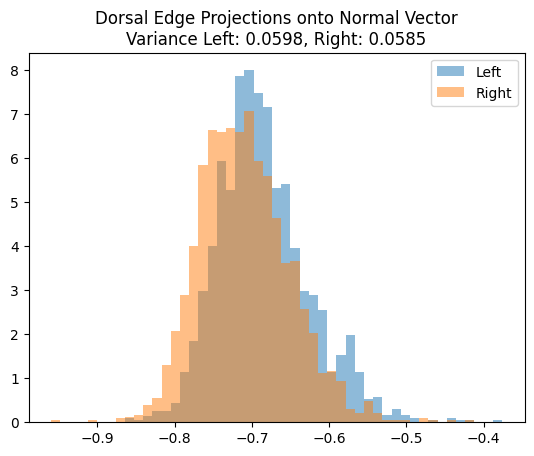

In [13]:
# assume dorsal edge is a plane, infer the normal vector using pca
from sklearn.decomposition import PCA
dorsal_edge_ccfs_flip = dorsal_edge_ccfs.copy()
dorsal_edge_ccfs_flip[:, ml] = np.abs(dorsal_edge_ccfs_flip[:, ml])
pca = PCA(n_components=3)
pca.fit(dorsal_edge_ccfs_flip)
normal_vector = pca.components_[-1]
print("Normal vector of dorsal edge plane:", normal_vector)
# project dorsal edge points onto the normal vector
dorsal_edge_proj_left = dorsal_edge_ccfs_left @ normal_vector
dorsal_edge_proj_right = dorsal_edge_ccfs_right @ normal_vector
var_l = np.var(dorsal_edge_proj_left)
sd_l = np.std(dorsal_edge_proj_left)
var_r = np.var(dorsal_edge_proj_right)
sd_r = np.std(dorsal_edge_proj_right)
# plot histogram of dorsal edge projections
plt.figure()
edges = np.linspace(min(dorsal_edge_proj_left.min(), dorsal_edge_proj_right.min()), max(dorsal_edge_proj_left.max(), dorsal_edge_proj_right.max()), 50)
plt.hist(dorsal_edge_proj_left, bins=edges, alpha=0.5, label='Left', density=True);
plt.hist(dorsal_edge_proj_right, bins=edges, alpha=0.5, label='Right', density=True);
plt.legend();
plt.title('Dorsal Edge Projections onto Normal Vector\nVariance Left: {:.4f}, Right: {:.4f}'.format(sd_l, sd_r))

Normal vector of dorsal surface plane: [0.90597767 0.03233549 0.42208871]


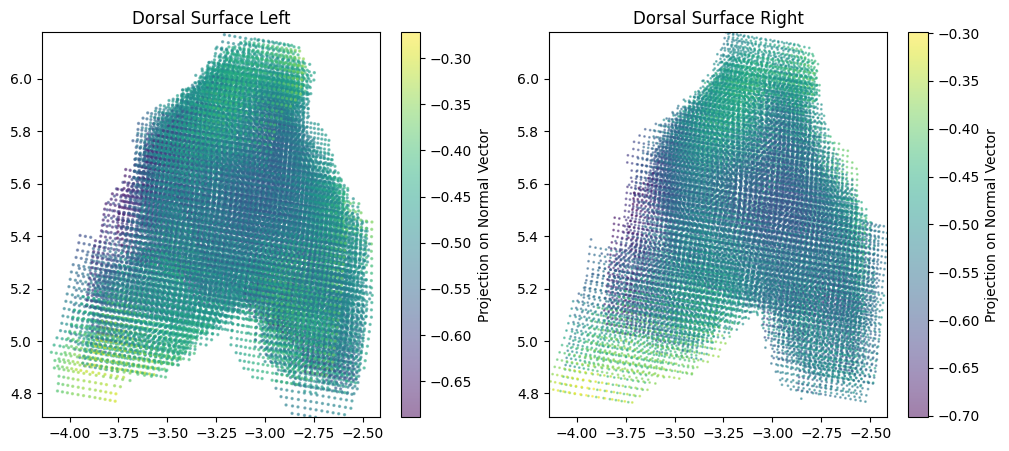

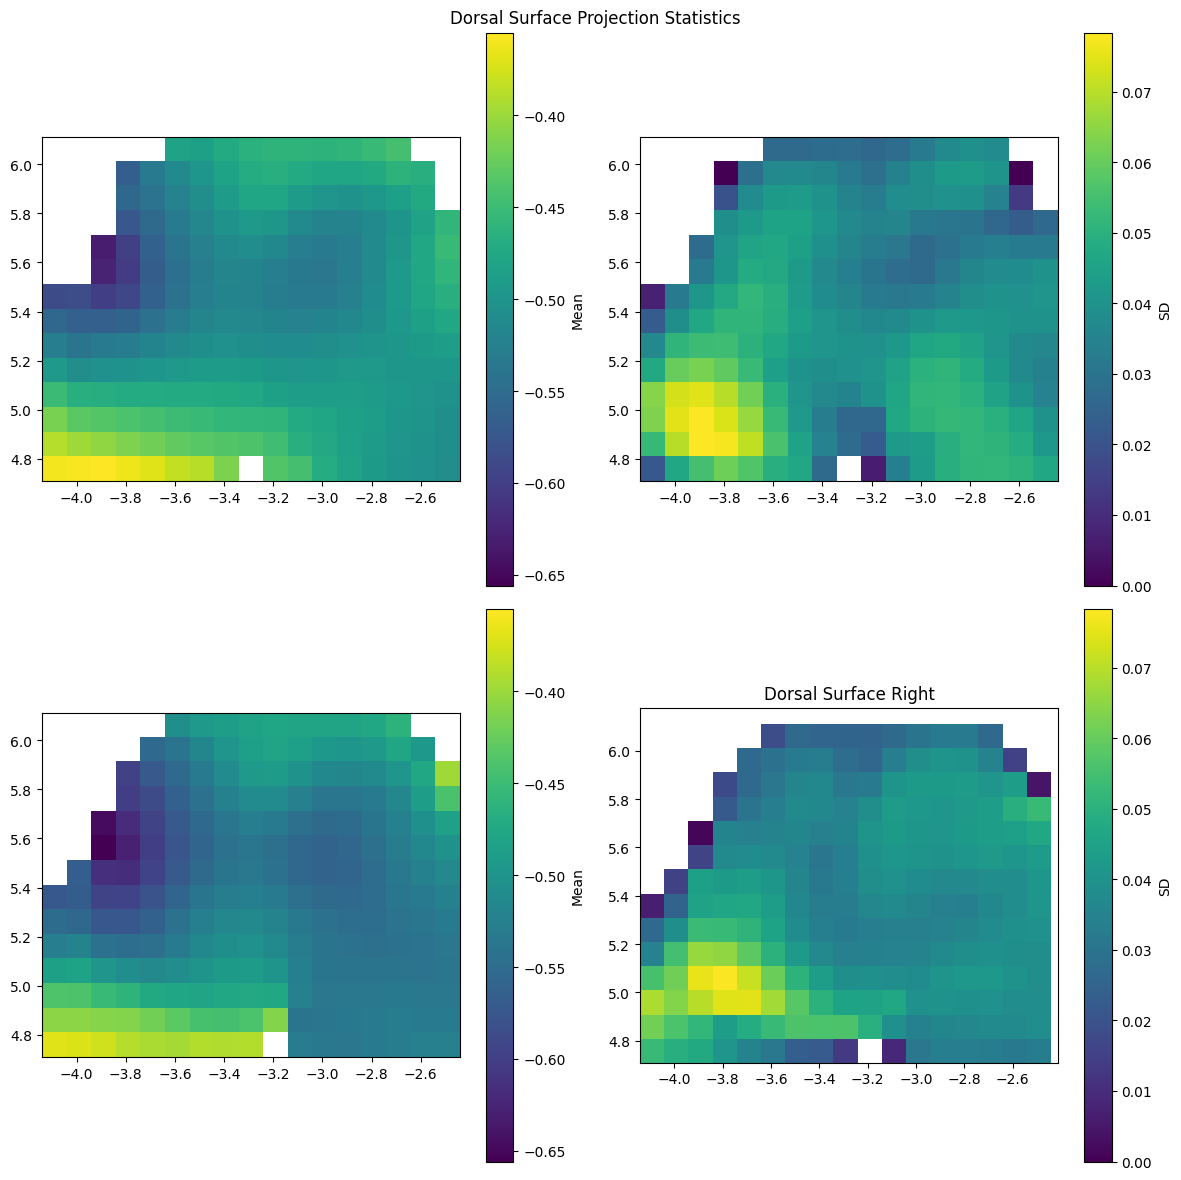

In [16]:
# infer the normal vector of the mesh using pca of the dorsal surface points
dorsal_surface_ccfs_all_flip = np.vstack([dorsal_surface_ccfs_L, dorsal_surface_ccfs_R])
dorsal_surface_ccfs_all = dorsal_surface_ccfs_all_flip.copy()
dorsal_surface_ccfs_all[len(dorsal_surface_ccfs_L):, ml] = -dorsal_surface_ccfs_all_flip[len(dorsal_surface_ccfs_L):, ml]
pca_surface = PCA(n_components=3)
pca_surface.fit(dorsal_surface_ccfs_all_flip)
normal_vector_surface = pca_surface.components_[-1]
print("Normal vector of dorsal surface plane:", normal_vector_surface)
# project dorsal surface points onto the normal vector
dorsal_surface_proj = dorsal_surface_ccfs_all_flip @ normal_vector_surface
# project dorsal surface onto the plane defined by the normal vector 1 and 2
dorsal_surface_proj_1 = dorsal_surface_ccfs_all_flip @ pca_surface.components_[0]
dorsal_surface_proj_2 = dorsal_surface_ccfs_all_flip @ pca_surface.components_[1]

xlim = (dorsal_surface_proj_1.min(), dorsal_surface_proj_1.max())
ylim = (dorsal_surface_proj_2.min(), dorsal_surface_proj_2.max())

# scatter proj_1 and proj_2 colored by proj on normal vector, separately for left and right on two plots
plt.figure(figsize=(12, 5))
ax = plt.subplot(1, 2, 1)
sc = ax.scatter(dorsal_surface_proj_1[dorsal_surface_ccfs_all[:, ml]>0], dorsal_surface_proj_2[dorsal_surface_ccfs_all[:, ml]>0], 
                c=dorsal_surface_proj[dorsal_surface_ccfs_all[:, ml]>0], cmap='viridis', s=2, alpha=0.5)
plt.colorbar(sc, label='Projection on Normal Vector')
plt.title('Dorsal Surface Left')
plt.xlim(xlim)
plt.ylim(ylim)
plt.subplot(1, 2, 2)
ax = plt.subplot(1, 2, 2)
sc = ax.scatter(dorsal_surface_proj_1[dorsal_surface_ccfs_all[:, ml]<0], dorsal_surface_proj_2[dorsal_surface_ccfs_all[:, ml]<0], 
                c=dorsal_surface_proj[dorsal_surface_ccfs_all[:, ml]<0], cmap='viridis', s=1, alpha=0.5)
plt.colorbar(sc, label='Projection on Normal Vector')
plt.title('Dorsal Surface Right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()

# plot mean and variance of retro ccf points from the dorsal surface plane binned by location of proj_1 and proj_2
bin_size = 0.2  # in mm
step_size = 0.1  # in mm
x_bins = np.arange(dorsal_surface_proj_1.min(), dorsal_surface_proj_1.max(), step_size)
y_bins = np.arange(dorsal_surface_proj_2.min(), dorsal_surface_proj_2.max(), step_size)
mean_proj_L = np.zeros((len(x_bins)-1, len(y_bins)-1))
var_proj_L = np.zeros((len(x_bins)-1, len(y_bins)-1))
mean_proj_R = np.zeros((len(x_bins)-1, len(y_bins)-1))
var_proj_R = np.zeros((len(x_bins)-1, len(y_bins)-1))
side_mask = dorsal_surface_ccfs_all[:, ml]>0
for i in range(len(x_bins)-1):
    for j in range(len(y_bins)-1):
        bin_mask = (dorsal_surface_proj_1 >= (x_bins[i]-0.5*bin_size)) & (dorsal_surface_proj_1 < (x_bins[i+1]+0.5*bin_size))& \
                   (dorsal_surface_proj_2 >= (y_bins[j]-0.5*bin_size)) & (dorsal_surface_proj_2 < (y_bins[j+1]+0.5*bin_size))
        # left
        if np.sum(bin_mask & side_mask) > 0:
            mean_proj_L[i, j] = np.mean(dorsal_surface_proj[bin_mask & side_mask])
            var_proj_L[i, j] = np.std(dorsal_surface_proj[bin_mask & side_mask])
        else:
            mean_proj_L[i, j] = np.nan
            var_proj_L[i, j] = np.nan
        # right
        if np.sum(bin_mask & ~side_mask) > 0:
            mean_proj_R[i, j] = np.mean(dorsal_surface_proj[bin_mask & ~side_mask])
            var_proj_R[i, j] = np.std(dorsal_surface_proj[bin_mask & ~side_mask])
        else:
            mean_proj_R[i, j] = np.nan
            var_proj_R[i, j] = np.nan

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
# separate left and right
im1 = axes[0, 0].imshow(mean_proj_L.T, origin='lower', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]], 
                vmin=min(np.nanmin(mean_proj_L), np.nanmin(mean_proj_R)), vmax=max(np.nanmax(mean_proj_L), np.nanmax(mean_proj_R)))
plt.colorbar(im1, ax=axes[0, 0], label='Mean')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title('Dorsal Surface Left')
im2 = axes[0, 1].imshow(var_proj_L.T, origin='lower', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                vmin=(min(np.nanmin(var_proj_L), np.nanmin(var_proj_R))), vmax=max(np.nanmax(var_proj_L), np.nanmax(var_proj_R)))
plt.colorbar(im2, ax=axes[0, 1], label='SD')
plt.xlim(xlim)
plt.ylim(ylim)
im3 = axes[1, 0].imshow(mean_proj_R.T, origin='lower', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                vmin=min(np.nanmin(mean_proj_L), np.nanmin(mean_proj_R)), vmax=max(np.nanmax(mean_proj_L), np.nanmax(mean_proj_R)))
plt.colorbar(im3, ax=axes[1, 0], label='Mean')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title('Dorsal Surface Right')
im4 = axes[1, 1].imshow(var_proj_R.T, origin='lower', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                vmin=min(np.nanmin(var_proj_L), np.nanmin(var_proj_R)), vmax=max(np.nanmax(var_proj_L), np.nanmax(var_proj_R)))
plt.colorbar(im4, ax=axes[1, 1], label='SD')
plt.xlim(xlim)
plt.ylim(ylim)
plt.suptitle('Dorsal Surface Projection Statistics')
plt.tight_layout()
plt.show()





Text(0.5, 1.0, 'Retro CCF Projections onto Dorsal Edge Normal Vector')

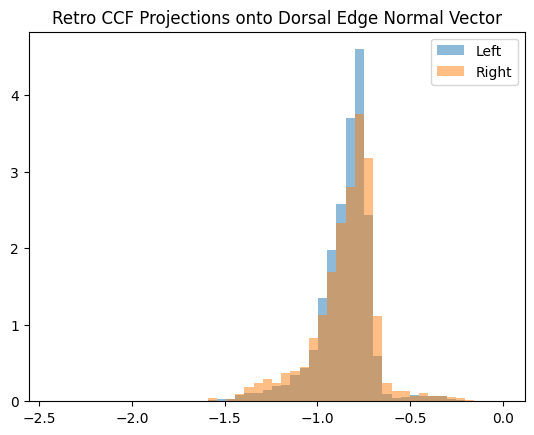

In [17]:
# Compare retro ccf points's left and right projections onto the normal vector
ccf_neurons_mm_L = ccf_neurons_mm[ccf_neurons_mm[:, ml]>0]
ccf_neurons_mm_R = ccf_neurons_mm[ccf_neurons_mm[:, ml]<0]
ccf_neurons_mm_R[:, ml] = -ccf_neurons_mm_R[:, ml]
ccf_proj_L = ccf_neurons_mm_L @ normal_vector
ccf_proj_R = ccf_neurons_mm_R @ normal_vector
# plot histogram of retro ccf projections
plt.figure()
edges = np.linspace(min(ccf_proj_L.min(), ccf_proj_R.min()), max(ccf_proj_L.max(), ccf_proj_R.max()), 50)
plt.hist(ccf_proj_L, bins=edges, alpha=0.5, label='Left', density=True);
plt.hist(ccf_proj_R, bins=edges, alpha=0.5, label='Right', density=True);
plt.legend();
plt.title('Retro CCF Projections onto Dorsal Edge Normal Vector')


In [18]:
# infer probability of projecting to each target region by inferring using RBFInterpolator
from sklearn.preprocessing import OneHotEncoder
projection_regions = retro_ccf['injection_region'].values.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
projection_regions_onehot = encoder.fit_transform(projection_regions)
# fit RBFInterpolator for each target region
rbf_models = {}
for i, region in enumerate(encoder.categories_[0]):
    y = projection_regions_onehot[:, i]
    rbf = RBFInterpolator(
        ccf_neurons_mm, y,
        kernel="linear",   # often nicer than "linear"
        smoothing=0.5,                # 0 == interpolate exactly
        neighbors=20,            # tune: 20–100 typical
        epsilon=1.0 
    )
    rbf_models[region] = rbf
# create a grid in the brain space to evaluate the probability
ap_grid = np.linspace(mesh_vertices_mm[:, ap].min(), mesh_vertices_mm[:, ap].max(), 50)
dv_grid = np.linspace(mesh_vertices_mm[:, dv].min(), mesh_vertices_mm[:, dv].max(), 50)
ml_grid = np.linspace(0, mesh_vertices_mm[:, ml].max(), 25)  # only left hemisphere
# create a mask to make sure the grid points are not too far from the sample points (0.2 mm)
mesh_kd_tree = cKDTree(ccf_neurons_mm)
AP, DV, ML = np.meshgrid(ap_grid, dv_grid, ml_grid)
query_pts_all = np.column_stack([ML.ravel(), AP.ravel(), DV.ravel()])
distances, _ = mesh_kd_tree.query(query_pts_all, k=1)
mask = distances < distance_threshold

query_pts = query_pts_all[mask]
# evaluate probability for each region
prob_maps = {}
for region, rbf in rbf_models.items():
    prob = rbf(query_pts)
    prob_map = np.zeros(AP.ravel().shape)
    prob_map[mask] = prob
    prob_map[~mask] = np.nan
    prob_maps[region] = prob_map.reshape(AP.shape)



In [30]:
import numpy as np
import k3d

# plot probability maps for each region in 3D space using k3d
for region, prob_map in prob_maps.items():
    plot = k3d.plot()
    # transparent gray mesh (downsample if this is huge)
    plot += k3d.points(
        mesh_vertices_mm_left.astype(np.float32),
        point_size=0.001,
        shader='flat',
        color=0xAAAAAA,
        opacity=0.1,
        name='CCF Mesh'
    )
    # flatten
    prob_values = np.asarray(prob_map).ravel()
    # mask must be computed from prob_values so points & values stay aligned
    valid_mask = np.isfinite(prob_values)  # True where not NaN/inf
    query_pts_region = query_pts_all[valid_mask]
    prob_values_region = prob_values[valid_mask]

    plot += k3d.points(
        query_pts_region.astype(np.float32),
        point_size=0.03,
        shader='flat',
        color_map=k3d.colormaps.matplotlib_color_maps.viridis,
        attribute=prob_values_region.astype(np.float32),
        name=f'Probability of {region}',
        opacity=0.6
    )

    plot.display()


Output()

Output()

Output()

Output()

In [34]:
# plot difference between each pair of two regions
region_list = list(prob_maps.keys())
for i in range(len(region_list)):
    for j in range(i+1, len(region_list)):
        if i >= j:
            continue
        region1 = region_list[i]
        region2 = region_list[j]
        prob_map1 = prob_maps[region1]
        prob_map2 = prob_maps[region2]
        diff_map = prob_map1 - prob_map2

        plot = k3d.plot()
        # transparent gray mesh (downsample if this is huge)
        plot += k3d.points(
            mesh_vertices_mm_left.astype(np.float32),
            point_size=0.01,
            shader='flat',
            color=0xAAAAAA,
            opacity=0.1,
            name='CCF Mesh'
        )
        # flatten
        diff_values = np.asarray(diff_map).ravel()
        # mask must be computed from diff_values so points & values stay aligned
        valid_mask = np.isfinite(diff_values)  # True where not NaN/inf
        query_pts_diff = query_pts_all[valid_mask]
        diff_values_region = diff_values[valid_mask]

        plot += k3d.points(
            query_pts_diff.astype(np.float32),
            point_size=0.015,
            shader='flat',
            color_map=k3d.colormaps.matplotlib_color_maps.seismic,
            attribute=diff_values_region.astype(np.float32),
            name=f'Difference: {region1} - {region2}',
            opacity=0.6
        )

        plot.display()


Output()

Output()

Output()

Output()

Output()

Output()

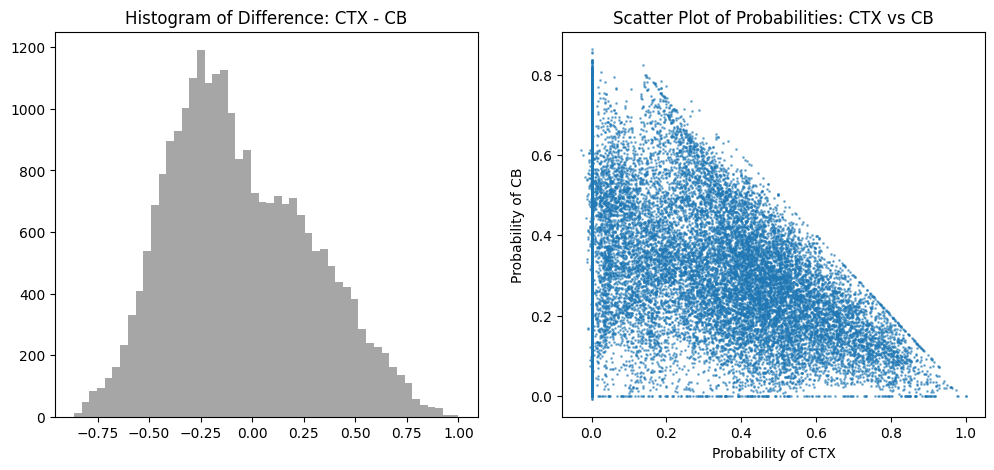

In [37]:
# plot histogram and scatter plot of the difference values between CTX and SP
region1 = 'CTX'
region2 = 'CB'
prob_map1 = prob_maps[region1]
prob_map2 = prob_maps[region2]
diff_map = prob_map1 - prob_map2
diff_values = np.asarray(diff_map).ravel()
valid_mask = np.isfinite(diff_values)
diff_values_region = diff_values[valid_mask]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# histogram
axes[0].hist(diff_values_region, bins=50, color='gray', alpha=0.7)
axes[0].set_title(f'Histogram of Difference: {region1} - {region2}')
# scatter plot
axes[1].scatter(prob_map1.ravel()[valid_mask], prob_map2.ravel()[valid_mask], alpha=0.5, s=1)
axes[1].set_xlabel(f'Probability of {region1}')
axes[1].set_ylabel(f'Probability of {region2}')
axes[1].set_title(f'Scatter Plot of Probabilities: {region1} vs {region2}')
plt.show()

In [41]:
# 3D scatter
region_1 = 'CTX'
region_2 = 'CB'
region_3 = 'SP'
prob_map_1 = prob_maps[region_1]
prob_map_2 = prob_maps[region_2]
prob_map_3 = prob_maps[region_3]
plot = k3d.plot()

# flatten
prob_values_1 = np.asarray(prob_map_1).ravel()
prob_values_2 = np.asarray(prob_map_2).ravel()
prob_values_3 = np.asarray(prob_map_3).ravel()

# plot values in 3D space
valid_mask = np.isfinite(prob_values_1) & np.isfinite(prob_values_2) & np.isfinite(prob_values_3)
# 1 2 and 3 are x axis y axis and z axis
query_pts_3d = query_pts_all[valid_mask]
prob_values_region_1 = prob_values_1[valid_mask]
prob_values_region_2 = prob_values_2[valid_mask]
prob_values_region_3 = prob_values_3[valid_mask]

plot = k3d.plot()

plot.axes = [
    f'Probability {region_1}',
    f'Probability {region_2}',
    f'Probability {region_3}'
]

plot += k3d.points(np.column_stack([prob_values_region_1, prob_values_region_2, prob_values_region_3]).astype(np.float32),
                    point_size=0.005,
                    shader='flat',
                    color=0xFF00FF,
                    name=f'3D Scatter: {region_1}, {region_2}, {region_3}',
                    opacity=0.6)
# set axes labels

plot.display()

Output()

In [44]:
# 3D scatter
region_1 = 'CTX'
region_2 = 'CB'
region_3 = 'SP'
prob_map_1 = prob_maps[region_1]
prob_map_2 = prob_maps[region_2]
prob_map_3 = prob_maps[region_3]
plot = k3d.plot()

# flatten
prob_values_1 = np.asarray(prob_map_1).ravel()
prob_values_2 = np.asarray(prob_map_2).ravel()
prob_values_3 = np.asarray(prob_map_3).ravel()

# log odd for each
prob_values_1 = np.log((prob_values_1 + 1e-4)/ ((1 - prob_values_1) + 1e-4))
prob_values_2 = np.log((prob_values_2 + 1e-4)/ ((1 - prob_values_2) + 1e-4))
prob_values_3 = np.log((prob_values_3 + 1e-4)/ ((1 - prob_values_3) + 1e-4))

# plot values in 3D space
valid_mask = np.isfinite(prob_values_1) & np.isfinite(prob_values_2) & np.isfinite(prob_values_3)
# 1 2 and 3 are x axis y axis and z axis
query_pts_3d = query_pts_all[valid_mask]
prob_values_region_1 = prob_values_1[valid_mask]
prob_values_region_2 = prob_values_2[valid_mask]
prob_values_region_3 = prob_values_3[valid_mask]

plot = k3d.plot()

plot.axes = [
    f'Probability {region_1}',
    f'Probability {region_2}',
    f'Probability {region_3}'
]

plot += k3d.points(np.column_stack([prob_values_region_1, prob_values_region_2, prob_values_region_3]).astype(np.float32),
                    point_size=0.01,
                    shader='flat',
                    color=0xFF00FF,
                    name=f'3D Scatter: {region_1}, {region_2}, {region_3}',
                    opacity=0.6)
# set axes labels

plot.display()

/tmp/ipykernel_1825173/2911142435.py:16: RuntimeWarning: invalid value encountered in log
  prob_values_1 = np.log((prob_values_1 + 1e-4)/ ((1 - prob_values_1) + 1e-4))
/tmp/ipykernel_1825173/2911142435.py:17: RuntimeWarning: invalid value encountered in log
  prob_values_2 = np.log((prob_values_2 + 1e-4)/ ((1 - prob_values_2) + 1e-4))
/tmp/ipykernel_1825173/2911142435.py:18: RuntimeWarning: invalid value encountered in log
  prob_values_3 = np.log((prob_values_3 + 1e-4)/ ((1 - prob_values_3) + 1e-4))


Output()

# Compare with behavior

In [47]:
beh_features_combined_file = '/root/capsule/scratch/combined/beh_plots/beh_all/features_combined_beh_all.pkl' 
with open(beh_features_combined_file, 'rb') as f:
    beh_combined = pd.read_pickle(f)
ccfs = beh_combined[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ml, ap, dv = 0, 1, 2
ccfs[:, ml] = np.abs(ccfs[:, ml]) 

In [48]:
ccf_neurons_mm_flip = ccf_neurons_mm.copy()
ccf_neurons_mm_flip[:, ml] = np.abs(ccf_neurons_mm_flip[:, ml])  # mirror to one side for cca projection

In [49]:
# plot ccfs with mesh and retro ccf
plot = k3d.plot()
# transparent gray mesh
plot += k3d.points(mesh_vertices_lps.astype(np.float32), point_size=0.01, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
# plot retro ccf ccf points
plot += k3d.points(ccf_neurons_mm_flip.astype(np.float32), point_size=0.005, shader='flat', color=0xFF0000, name='Retro CCF', opacity=0.5)
# plot beh ccfs points
plot += k3d.points(ccfs.astype(np.float32), point_size=0.05, shader='flat', color=0x0000FF, name='Beh CCF', opacity=0.5)
plot.display()

Output()

In [50]:
beh_location_tree = cKDTree(ccfs[~np.isnan(ccfs[:, ml]), :])
distance = 0.1
close_mask, _ = beh_location_tree.query(ccf_neurons_mm_flip, k=1)  # only infer for points within 0.3 mm of any beh point
close_mask = close_mask<distance

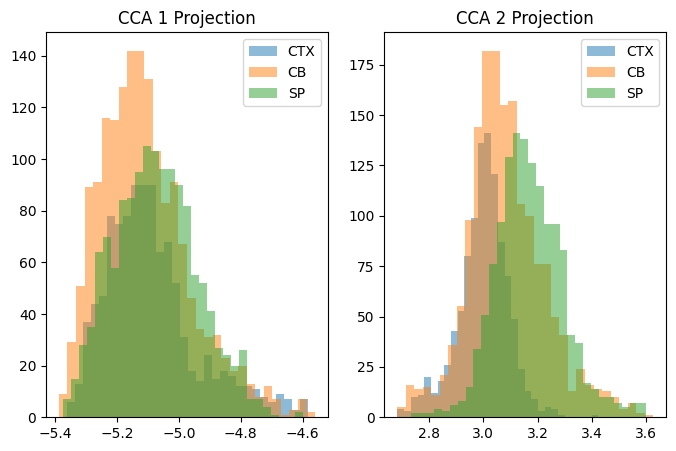

In [51]:
# plot distibution of projection targets along cca1 and cca2
cca_1 = np.array([-0.2636, -0.9645, -0.0140])
cca_2 = np.array([-0.7005, 0.2014, -0.6847])

ccf_neurons_mm_flip = ccf_neurons_mm.copy()
ccf_neurons_mm_flip[:, ml] = np.abs(ccf_neurons_mm_flip[:, ml])  # mirror to one side for cca projection
cca_1_proj = ccf_neurons_mm_flip @ cca_1
cca_2_proj = ccf_neurons_mm_flip @ cca_2

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
    if tar != 'TH':
        mask = (retro_ccf['injection_region'] == tar)
        axes[0].hist(cca_1_proj[mask & close_mask], bins=30, alpha=0.5, label=tar)
        axes[1].hist(cca_2_proj[mask & close_mask], bins=30, alpha=0.5, label=tar)
axes[0].set_title('CCA 1 Projection')
axes[1].set_title('CCA 2 Projection')
axes[0].legend()
axes[1].legend()
plt.show()

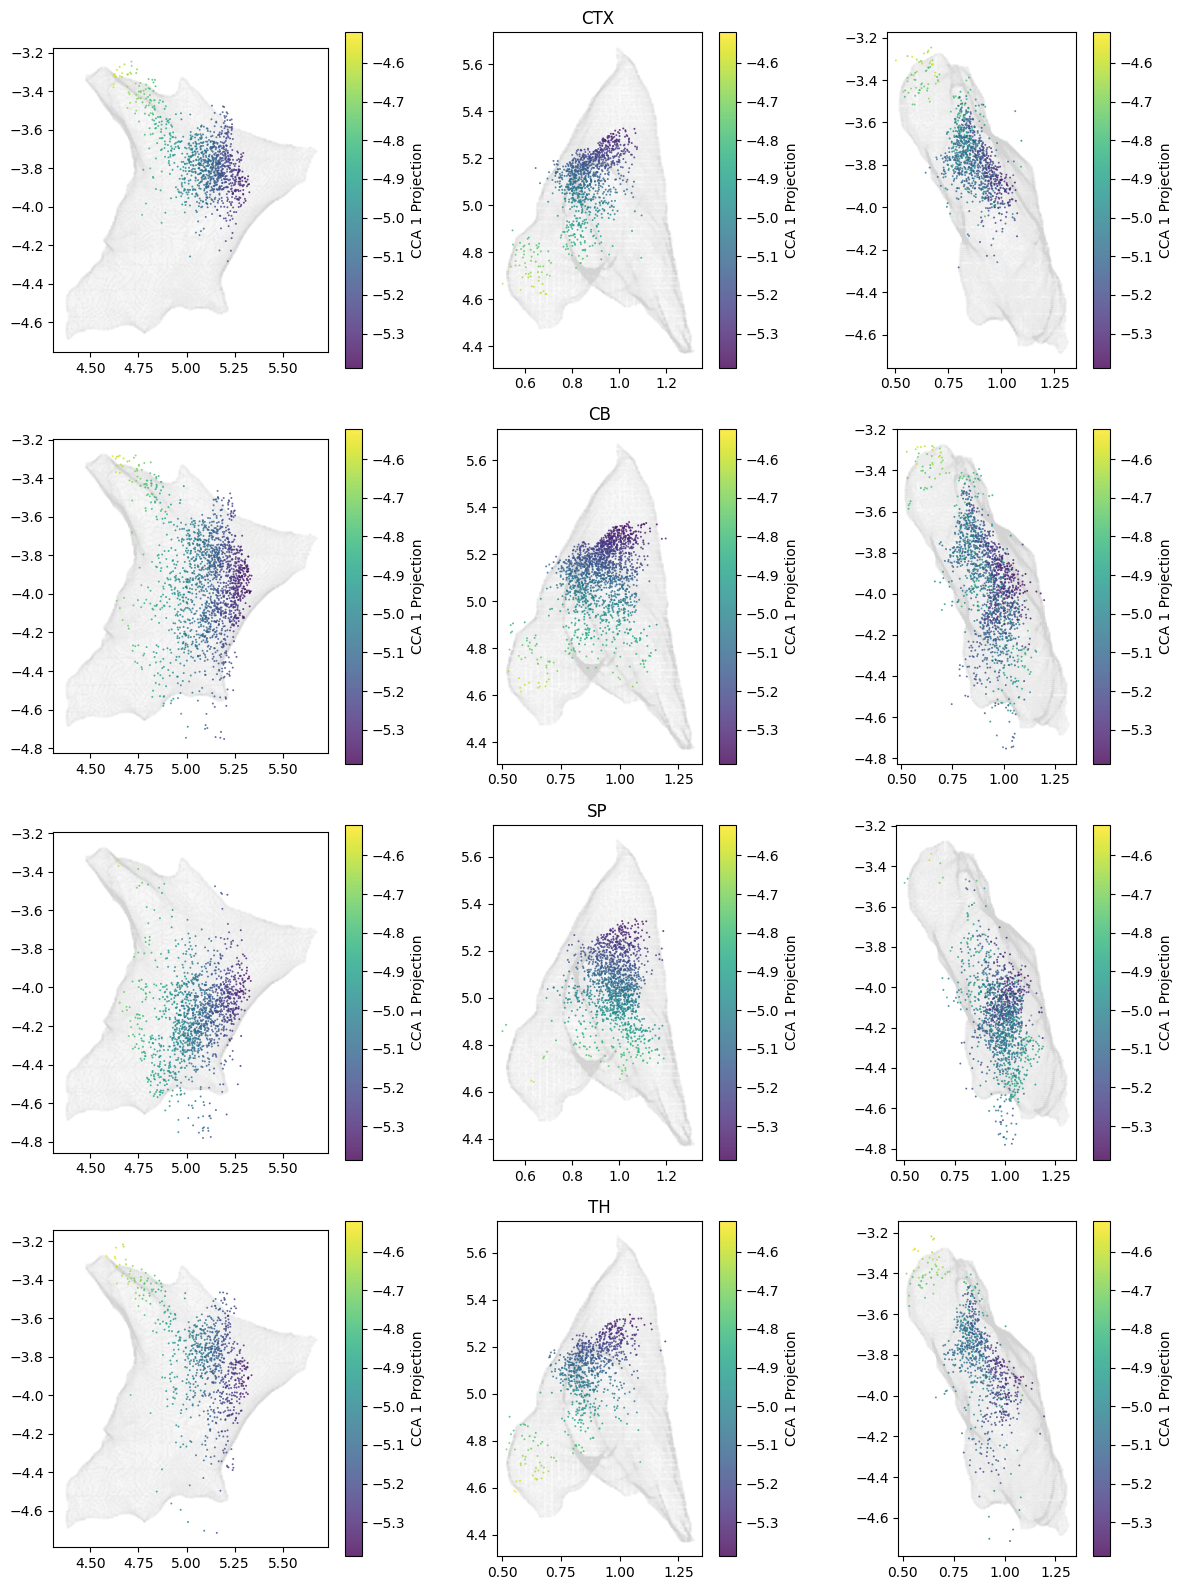

In [52]:
# color code points by their projection on cca1 and cca2
fig = plt.figure(figsize=(12, 4*len(retro_ccf['injection_region'].unique())))
gs = fig.add_gridspec(len(retro_ccf['injection_region'].unique()), 3)
norm = Normalize(vmin=np.min(cca_1_proj[close_mask]), vmax=np.max(cca_1_proj[close_mask]))
for plane, ax_ind in zip(planes.keys(), range(3)):
    # ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
        mask = (retro_ccf['injection_region'] == tar)
        ax = fig.add_subplot(gs[ind, ax_ind])
        ax.scatter(mesh_vertices_lps[:, planes[plane][0]], mesh_vertices_lps[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
        
        sc = ax.scatter(ccf_neurons_mm_flip[mask & close_mask, planes[plane][0]], ccf_neurons_mm_flip[mask & close_mask, planes[plane][1]], c=cca_1_proj[mask & close_mask], cmap='viridis', alpha=0.8, s=2, edgecolor='none', label=tar, norm=norm)
        plt.colorbar(sc, ax=ax, label='CCA 1 Projection')
        ax.set_aspect(aspect='equal')
        if plane == 'hor':
            ax.set_title(tar)
    # ax.set_title(plane)
plt.tight_layout()
plt.show()

In [53]:
beh_features = ['T_outcome:ipsi_com_mc',
                'T_outcome_l_mc',
                'T_outcome_com_mc',
                'T_ipsi_com_mc',
                'T_ipsi_l_mc',
                'T_response_hit_all',
                'T_response_svs_hit',
                'T_response_ipsi_hit',
                'T_response_ipsi:svs_hit']

In [54]:
# for each feature, x = [ccf in 3 dimensions], y = [feature value], infer feature value of neurons in retro_ccf using rbf
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_projections = {}

beh_location_tree = cKDTree(ccfs[~np.isnan(ccfs[:, ml]), :])
distance = 0.1
close_mask, _ = beh_location_tree.query(ccf_neurons_mm_flip, k=1)  # only infer for points within 0.3 mm of any beh point
close_mask = close_mask<distance
for feature in beh_features:
    feature_values = beh_combined[feature].values
    valid_mask = ~np.isnan(feature_values) & ~np.isnan(ccfs[:, ml])
    rbf = RBFInterpolator(
        ccfs[valid_mask], feature_values[valid_mask],
        kernel="gaussian",   
        smoothing=0.5,                # 0 == interpolate exactly
        neighbors=3,            # tune: 20–100 typical
        epsilon=0.5 
    )
    # infer feature values for retro ccf neurons
    inferred_values = rbf(ccf_neurons_mm_flip)
    inferred_values[~close_mask] = np.nan  # set to nan if not close to any beh point
    feature_projections[feature] = inferred_values

In [55]:
import matplotlib.gridspec as gridspec
regions = ['CTX', 'SP', 'CB']
custom_cmap = LinearSegmentedColormap.from_list(
    'blue_white_red', [(0.0, 'red'), (0.5, 'white'), (1.0, 'blue')]
)
for test_feature in beh_features:
    fig = plt.figure(figsize=(18, 15))
    gs = gridspec.GridSpec(len(regions)+1, len(planes))
    max_scale = np.nanmax(np.abs(feature_projections[test_feature][close_mask]))
    norm = Normalize(vmin=-max_scale, vmax=max_scale)
    ax_hist = fig.add_subplot(gs[-1, 0])
    edges = np.linspace(np.min(feature_projections[test_feature][close_mask])-0.01, np.max(feature_projections[test_feature][close_mask])+0.01, 20)
    for tar_ind, tar in enumerate(regions):
        mask = (retro_ccf['injection_region'] == tar)
        for i, plane in enumerate(planes.keys()):
            ax = fig.add_subplot(gs[tar_ind, i])
            sc = ax.scatter(ccf_neurons_mm_flip[mask, planes[plane][0]], ccf_neurons_mm_flip[mask, planes[plane][1]], 
                        c=feature_projections[test_feature][mask], cmap=custom_cmap, s=2, alpha=0.6, label=tar, norm=norm)
            # scatter mesh
            ax.scatter(mesh_vertices_mm_left[:, planes[plane][0]], mesh_vertices_mm_left[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
            if i == 0:
                ax.set_ylabel(tar)
                plt.colorbar(sc, ax=ax, label=test_feature)
            ax.set_aspect(aspect='equal')
        if tar != 'CB':
            ax_hist.hist(feature_projections[test_feature][mask & close_mask], bins=edges, alpha=0.7, label=tar)
    ax_hist.legend()
    # Compare if distribution of feature projections are different between CTX and SP
    ctx_mask = (retro_ccf['injection_region'] == 'CTX') & close_mask
    sp_mask = (retro_ccf['injection_region'] == 'SP') & close_mask
    t_stat, p_value = ttest_ind(feature_projections[test_feature][ctx_mask], feature_projections[test_feature][sp_mask], nan_policy='omit')
    ax_hist.set_title(f'Histogram (p-value CTX vs SP: {p_value:.4f})')
    plt.suptitle(f'Inferred {test_feature} on Retro CCF Neurons')
    plt.tight_layout()
    fig.savefig(fname=os.path.join(save_dir, f'{test_feature}_inferred_on_retro_ccf.png'), dpi=300)
    fig.savefig(fname=os.path.join(save_dir, f'{test_feature}_inferred_on_retro_ccf.pdf'))
    plt.close(fig)

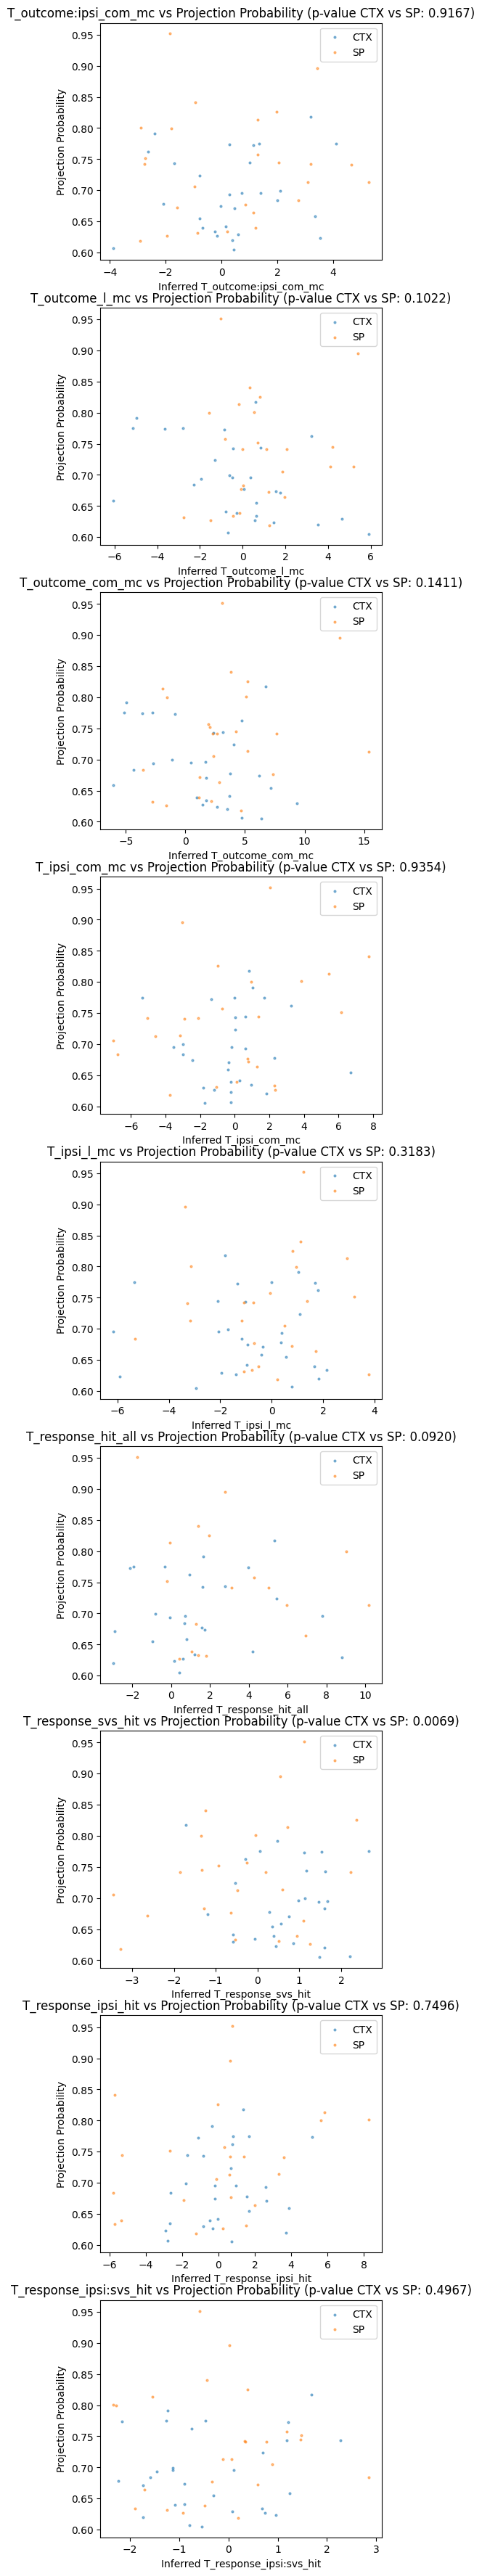

In [79]:
# plot beh_feautures against probability of projecting to different regions
fig = plt.figure(figsize=(5, 5*len(beh_features)))
gs = gridspec.GridSpec(len(beh_features), 1)

proj_beh = {}
valid_mask = ~np.isnan(ccfs).any(axis=1)
thresholds = {'this_region': 0.6, 'other_regions': 0.3}
for proj in regions:
    proj_p_curr = np.full(ccfs.shape[0], np.nan)
    proj_p_curr[valid_mask] = rbf_models[proj](ccfs[valid_mask])
    proj_beh[proj] = proj_p_curr
    
for feat_ind, feat in enumerate(beh_features):
    ax = fig.add_subplot(gs[feat_ind, 0])
    inferred_features = {}
    for tar in regions:
        if tar != 'CB':
            # infer probably of projecting to tar based on rbf model
            p_proj = proj_beh[tar]
            proj_mask = p_proj >= thresholds['this_region']
            for other_tar in regions:
                if other_tar != tar:
                    proj_mask &= (proj_beh[other_tar] <= thresholds['other_regions'])
            inferred_features[tar] = beh_combined[feat][valid_mask&proj_mask]
            ax.scatter(beh_combined[feat][valid_mask&proj_mask], p_proj[valid_mask&proj_mask], alpha=0.5, s=4, label=tar)
    # compare distributions between regions CTX and SP
    ctx_feat = inferred_features['CTX']
    sp_feat = inferred_features['SP']
    t_stat, p_value = ttest_ind(ctx_feat, sp_feat, nan_policy='omit')
    ax.set_title(f'{feat} vs Projection Probability (p-value CTX vs SP: {p_value:.4f})')
    ax.set_xlabel(f'Inferred {feat}')
    ax.set_ylabel('Projection Probability')
    ax.legend()
    # ax.set_title(f'{feat} vs Projection Probability')


In [86]:
# plot the projection mask in ccf space using k3d
thresholds = {'this_region': 0.6, 'other_regions': 0.3}
valid_mask = ~np.isnan(ccfs).any(axis=1)
for proj in regions:
    proj_p_curr = np.full(ccfs.shape[0], np.nan)
    proj_p_curr[valid_mask] = rbf_models[proj](ccfs[valid_mask])
    proj_beh[proj] = proj_p_curr

        # valid_mask = np.isfinite(diff_values)  # True where not NaN/inf
        # query_pts_diff = query_pts_all[valid_mask]
for proj in regions:
    proj_p_curr = proj_beh[proj]
    proj_mask = proj_p_curr >= thresholds['this_region']
    for other_tar in regions:
        if other_tar != proj:
            proj_mask &= (proj_beh[other_tar] <= thresholds['other_regions'])
    
    sampling_mask = prob_maps[proj].ravel() >= thresholds['this_region']
    for other_tar in regions:
        if other_tar != proj:
            sampling_mask &= (prob_maps[other_tar].ravel() <= thresholds['other_regions'])

    
    plot = k3d.plot()
    # transparent gray mesh
    plot += k3d.points(mesh_vertices_lps.astype(np.float32), point_size=0.01, shader='flat', color=0xAAAAAA, opacity=0.1, name='CCF Mesh')
    # plot projection mask points
    plot += k3d.points(ccfs[valid_mask & proj_mask].astype(np.float32), point_size=0.03, shader='flat', color=0x00FF00, name=f'Projection Mask: {proj}', opacity=0.6)
    # plot all samples
    plot += k3d.points(query_pts_all[sampling_mask].astype(np.float32), point_size=0.01, shader='flat', color=0xFF0000, name=f'Sampled Points: {proj}', opacity=0.3)
    plot.display()

Output()

Output()

Output()

In [85]:
sampling_mask.shape

(50, 50, 25)

In [ ]:
# Step 4: Get the primary axis of variation
# LDA provides a linear discriminant, which can be interpreted as the primary axis of variation
primary_axis_vector = lda.scalings_[:, 0]  # First linear discriminant

# Normalize the vector for better interpretation
primary_axis_vector_LDA = primary_axis_vector / np.linalg.norm(primary_axis_vector)
 
# Display the primary axis of variation
print("Primary axis of variation :", primary_axis_vector_LDA)


Primary axis of variation : [0.22827885 0.95594934 0.1845254 ]


# Infer waveform properties

In [ ]:
# load waveforms
waveform_criteria = 'waveform_all'
waveform_type = '_raw'
wf_folder  = os.path.join('/root/capsule/scratch/combined/wf_plots', waveform_criteria, waveform_type)
wf_feature_file = os.path.join(wf_folder, 'wf_features_combined.pkl')
with open(wf_feature_file, 'rb') as f:
    wf_features = pickle.load(f)
wf_features.rename(columns={'unit': 'unit_id'}, inplace=True)
wf_features['unit_id'] = wf_features['unit_id'].apply(to_str_intlike)
wf_features.drop(columns=['probe'], inplace=True)

features_wf = wf_features.columns.to_list()
features_wf.remove('session')
features_wf.remove('unit_id')
features_wf.remove('wf')
# features_wf.remove('gmm_label')
# features_wf.remove('kmeans_label')
# features_wf.remove('gmm_conf')
features_wf.remove('y_loc')
# features_wf.remove('probe')
features_wf.remove('peak')
features_wf.remove('amp')

with open(os.path.join('/root/capsule/scratch/combined/combine_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
combined_tagged_units.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)

wf_features = wf_features.merge(combined_tagged_units[['session', 'unit_id', 'x_ccf', 'y_ccf', 'z_ccf']], on=['session', 'unit_id'], how='left')

In [ ]:
ccfs = wf_features[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])

In [ ]:
# generate close_mask for wf features
beh_location_tree = cKDTree(ccfs[~np.isnan(ccfs[:, ml]), :])
distance = 0.1
close_mask, _ = beh_location_tree.query(ccf_neurons_mm_flip, k=1)  # only infer for points within 0.1 mm of any beh point
close_mask = close_mask<distance

In [ ]:
# infer each wf feature on retro ccf neurons
wf_feature_projections = {}
for feature in features_wf:
    feature_values = wf_features[feature].values
    valid_mask = ~np.isnan(feature_values) & ~np.isnan(ccfs[:, ml])
    rbf = RBFInterpolator(
        ccfs[valid_mask], feature_values[valid_mask],
        kernel="gaussian",   
        smoothing=0.5,                # 0 == interpolate exactly
        neighbors=3,            # tune: 20–100 typical
        epsilon=0.5 
    )
    # infer feature values for retro ccf neurons
    inferred_values = rbf(ccf_neurons_mm_flip)
    inferred_values[~close_mask] = np.nan  # set to nan if not close to any beh point
    wf_feature_projections[feature] = inferred_values

In [ ]:
# plot each wf feature on retro ccf neurons
import matplotlib.gridspec as gridspec
regions = ['CTX', 'SP', 'CB']
custom_cmap = LinearSegmentedColormap.from_list('gray_red', [(0.0, 'gray'), (1.0, 'red')])
for test_feature in features_wf:
    fig = plt.figure(figsize=(18, 15))
    gs = gridspec.GridSpec(len(regions)+1, len(planes))
    norm = Normalize(vmin=np.nanmin(wf_feature_projections[test_feature][close_mask]), vmax=np.nanmax(wf_feature_projections[test_feature][close_mask]))
    ax_hist = fig.add_subplot(gs[-1, 0])
    edges = np.linspace(np.min(wf_feature_projections[test_feature][close_mask])-0.01, np.max(wf_feature_projections[test_feature][close_mask])+0.01, 20)
    for tar_ind, tar in enumerate(regions):
        mask = (retro_ccf['injection_region'] == tar)
        for i, plane in enumerate(planes.keys()):
            ax = fig.add_subplot(gs[tar_ind, i])
            sc = ax.scatter(ccf_neurons_mm_flip[mask, planes[plane][0]], ccf_neurons_mm_flip[mask, planes[plane][1]], 
                        c=wf_feature_projections[test_feature][mask], cmap=custom_cmap, s=2, alpha=0.6, label=tar, norm=norm)
            # scatter mesh
            ax.scatter(mesh_vertices_mm_left[:, planes[plane][0]], mesh_vertices_mm_left[:, planes[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
            if i == 0:
                ax.set_ylabel(tar)
                plt.colorbar(sc, ax=ax, label=test_feature)
            ax.set_aspect(aspect='equal')
        if tar != 'CB':
            ax_hist.hist(wf_feature_projections[test_feature][mask & close_mask], bins=edges, alpha=0.7, label=tar)
    ax_hist.legend()
    # ttest
    ctx_mask = (retro_ccf['injection_region'] == 'CTX') & close_mask
    sp_mask = (retro_ccf['injection_region'] == 'SP') & close_mask
    t_stat, p_value = ttest_ind(wf_feature_projections[test_feature][ctx_mask], wf_feature_projections[test_feature][sp_mask], nan_policy='omit')
    ax_hist.set_title(f'Histogram (p-value CTX vs SP: {p_value:.4f})')
    plt.suptitle(f'Inferred {test_feature} on Retro CCF Neurons')
    plt.tight_layout()
    fig.savefig(fname=os.path.join(save_dir, f'{test_feature}_inferred_on_retro_ccf.png'), dpi=300)
    fig.savefig(fname=os.path.join(save_dir, f'{test_feature}_inferred_on_retro_ccf.pdf'))
    plt.close(fig)

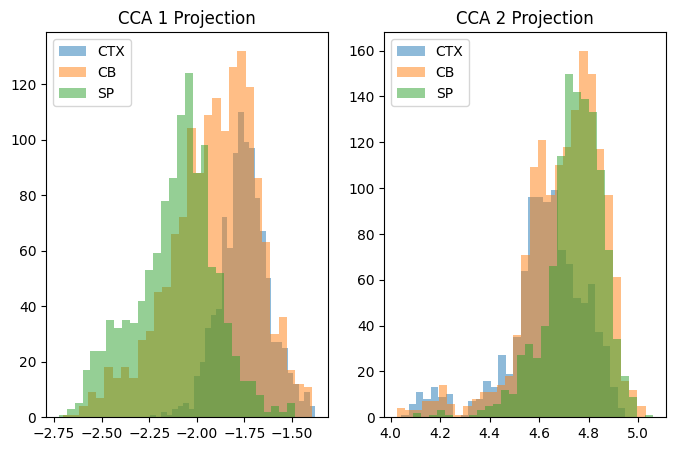

In [ ]:
# project to cca axes and plot histograms
cca_1 = np.array([-0.1449, 0.3623, 0.9207])
cca_2 = np.array([0.7233, 0.6738, -0.1512])
cca_1_proj = ccf_neurons_mm_flip @ cca_1
cca_2_proj = ccf_neurons_mm_flip @ cca_2

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
    if tar != 'TH':
        mask = (retro_ccf['injection_region'] == tar)
        axes[0].hist(cca_1_proj[mask & close_mask], bins=30, alpha=0.5, label=tar)
        axes[1].hist(cca_2_proj[mask & close_mask], bins=30, alpha=0.5, label=tar)
axes[0].set_title('CCA 1 Projection')
axes[1].set_title('CCA 2 Projection')
axes[0].legend()
axes[1].legend()
fig.savefig(fname=os.path.join(save_dir, f'wf_cca1_cca2_projection_histograms.png'), dpi=300)
fig.savefig(fname=os.path.join(save_dir, f'wf_cca1_cca2_projection_histograms.pdf'))
plt.show()


# Infer primary from regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.api as sm

# filter = projection_regions != 'TH'
filter = ((projection_regions == 'CTX') | (projection_regions == 'SP')) & (ccf_neurons_mm[:, dv_mesh] <= 4.8)
# Assume X is your features and y is binary or multiclass target
ccf_neurons_mm_with_const = sm.add_constant(ccf_neurons_mm)  # Add intercept
projection_regions_bin = projection_regions == 'SP'
# model = sm.MNLogit(projection_regions[filter], ccf_neurons_mm_with_const[filter])  # For multinomial; use sm.Logit for binary
model = sm.Logit(projection_regions_bin[filter], ccf_neurons_mm_with_const[filter]) 
result = model.fit()

# Get 95% confidence intervals
ci = result.conf_int(alpha=0.05)
primary_axis_vector_MLR = result.params[1:] * np.sign(result.params[2])  # First linear discriminant
primary_axis_vector_MLR = primary_axis_vector_MLR / np.linalg.norm(primary_axis_vector_MLR)
# Display the primary axis of variation
print("Primary axis of variation (in MLR space):", primary_axis_vector_MLR)

NameError: name 'dv_mesh' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.api as sm

# filter = projection_regions != 'TH'
filter = ((projection_regions == 'CTX') | (projection_regions == 'SP')) & (ccf_neurons_mm[:, dv_mesh] <= 4.8)
# Assume X is your features and y is binary or multiclass target
ccf_neurons_mm_with_const = sm.add_constant(ccf_neurons_mm)  # Add intercept
projection_regions_bin = projection_regions == 'SP'

model = sm.OLS(projection_regions_bin[filter], ccf_neurons_mm_with_const[filter])
# model = sm.Logit(projection_regions_bin[filter], ccf_neurons_mm_with_const[filter])  # For binary logistic regression
model = model.fit()
print(model.summary())
print(model.params[1:]/np.linalg.norm(model.params[1:]))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     2512.
Date:                Tue, 10 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:55:35   Log-Likelihood:                -1501.2
No. Observations:                5302   AIC:                             3010.
Df Residuals:                    5298   BIC:                             3037.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2833      0.134    -17.039      0.0

In [ ]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 5302
Model:                          Logit   Df Residuals:                     5298
Method:                           MLE   Df Model:                            3
Date:                Tue, 10 Jun 2025   Pseudo R-squ.:                  0.6413
Time:                        23:47:06   Log-Likelihood:                -1317.6
converged:                       True   LL-Null:                       -3673.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.5355      2.098     -6.929      0.000     -18.647     -10.424
x1             5.1088      0.339     15.074      0.000       4.445       5.773
x2             9.2369      0.356     25.937      0.0

In [ ]:
model.params

array([-2.28332857,  0.25583379,  1.07133945,  0.20679897])

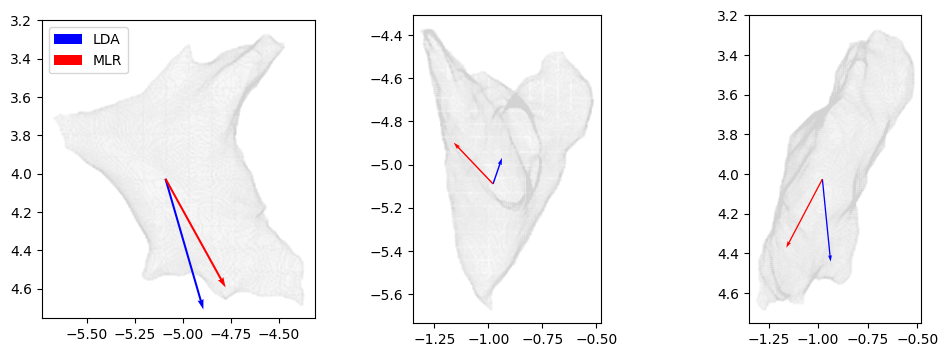

In [ ]:
# plot the two axis in 2D ccf space
fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(1, 3)
for plane, ax_ind in zip(planes.keys(), range(3)):
    ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    ax.scatter(mesh_vertices_mm[:, planes_mesh[plane][0]], mesh_vertices_mm[:, planes_mesh[plane][1]], color='lightgray', alpha=0.1, s = 0.1)
    # sc = ax.scatter(ccf_neurons_mm[mask, planes_mesh[plane][0]], ccf_neurons_mm[mask, planes_mesh[plane][1]], color='r', alpha=0.2, s=1, edgecolor='none', label=tar)
    if planes[plane][1] == dv:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_LDA[planes_mesh[plane][0]], -primary_axis_vector_LDA[planes_mesh[plane][1]],scale=2, color='blue', label='LDA')
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], -primary_axis_vector_MLR[planes_mesh[plane][1]],scale=2, color='red', label='MLR')
    else:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_LDA[planes_mesh[plane][0]], primary_axis_vector_LDA[planes_mesh[plane][1]],scale=2, color='blue', label='LDA')
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], primary_axis_vector_MLR[planes_mesh[plane][1]],scale=2, color='red', label='MLR')
    ax.set_aspect(aspect='equal')
    if planes[plane][1] == dv:
        ax.invert_yaxis()
    # ax.set_title(plane)
    if plane == 'sag':
        ax.legend()

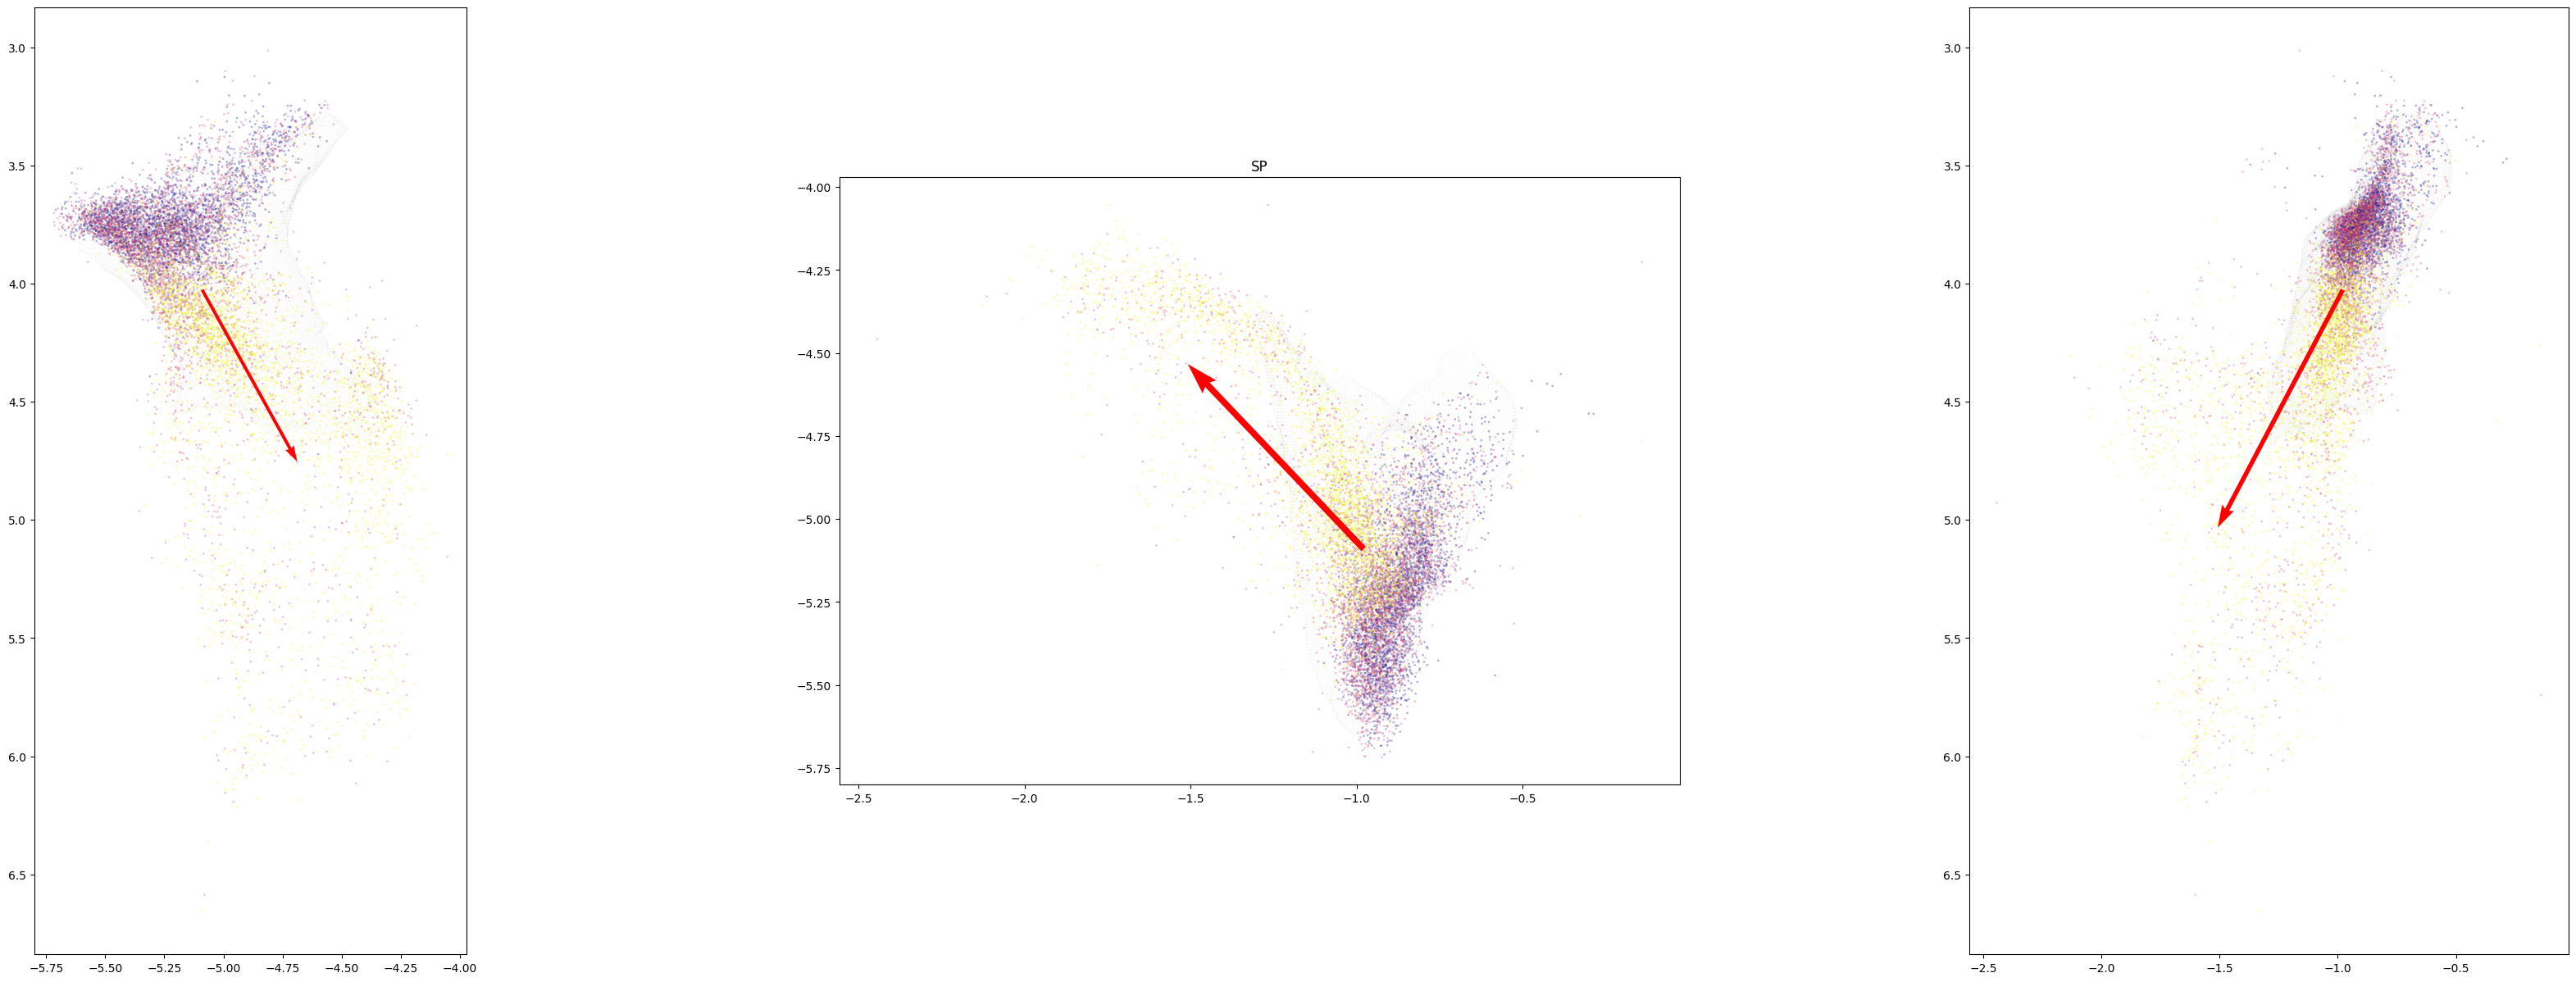

In [ ]:
fig = plt.figure(figsize=(45, 15))
gs = fig.add_gridspec(1, 3)
from matplotlib.cm import plasma
from matplotlib.colors import to_hex

category_order = ['CTX', 'CB', 'SP']
category_to_index = {cat: i for i, cat in enumerate(category_order)}

# Normalize indices to [0, 1] for colormap
norm_indices = [category_to_index[cat] / (len(category_order) - 1) for cat in category_order]
colors = [plasma(val) for val in norm_indices]

for plane, ax_ind in zip(planes.keys(), range(3)):
    ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    ax.scatter(mesh_vertices_mm[:, planes_mesh[plane][0]], mesh_vertices_mm[:, planes_mesh[plane][1]], color='lightgray', alpha=0.1, s = 0.02)
    for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
        mask = (retro_ccf['injection_region'] == tar)
        if tar == 'TH':
            continue
        sc = ax.scatter(ccf_neurons_mm[mask, planes_mesh[plane][0]], ccf_neurons_mm[mask, planes_mesh[plane][1]], color=colors[category_order.index(tar)], alpha=0.3, s=4, edgecolor='none', label=tar)
        ax.set_aspect(aspect='equal')
        if planes[plane][1] == dv:
            ax.invert_yaxis()
        if plane == 'hor':
            ax.set_title(tar)
    if planes[plane][1] == dv:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], -primary_axis_vector_MLR[planes_mesh[plane][1]],scale=2, color='red', label='MLR')
    else:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], primary_axis_vector_MLR[planes_mesh[plane][1]],scale=2, color='red', label='MLR')
    # ax.set_title(plane)

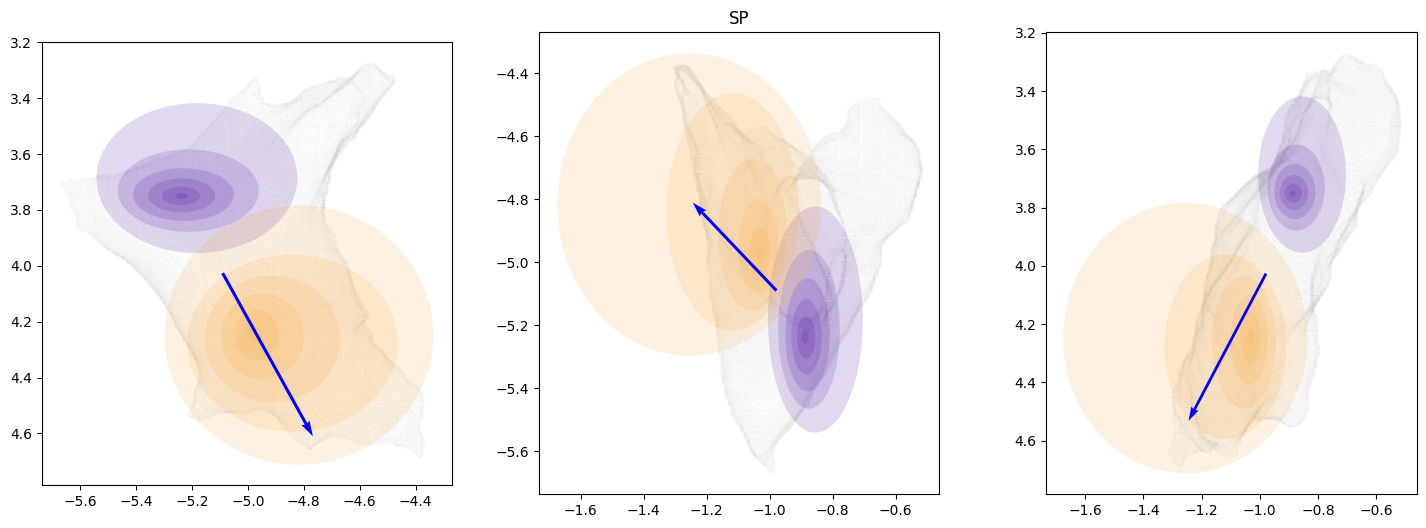

In [ ]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3)
from matplotlib.cm import plasma
from matplotlib.colors import to_hex
from matplotlib.patches import Ellipse

category_order = ['CTX', 'SP']
category_to_index = {cat: i for i, cat in enumerate(category_order)}

# Normalize indices to [0, 1] for colormap
norm_indices = [0.1, 0.8]
colors = [plasma(val) for val in norm_indices]
ccf_neurons_mm_center_mask = ccf_neurons_mm[:, dv]<=4.8
centers =[np.mean(ccf_neurons_mm[(retro_ccf['injection_region'] == tar) & (ccf_neurons_mm_center_mask)], axis=0) for tar in category_order]
centers = np.array(centers)
bin_count = 12
pers = np.linspace(5, 95, bin_count)
sds = [np.percentile(ccf_neurons_mm[(retro_ccf['injection_region'] == tar) & (ccf_neurons_mm_center_mask)], pers, axis=0) for tar in category_order]
sds = np.array(sds)

for plane, ax_ind in zip(planes.keys(), range(3)):
    ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    ax.scatter(mesh_vertices_mm[:, planes_mesh[plane][0]], mesh_vertices_mm[:, planes_mesh[plane][1]], color='lightgray', alpha=0.7, s = 0.002)
    for ind, tar in enumerate(category_order):
        for ind_per in range(int(0.5*bin_count)):
            inds = np.array([ind_per, bin_count-1-ind_per])
            center = np.mean(sds[ind, inds, planes_mesh[plane][0]]), np.mean(sds[ind, inds, planes_mesh[plane][1]])
            width = (sds[ind, bin_count-1-ind_per, planes_mesh[plane][0]] - sds[ind, ind_per, planes_mesh[plane][0]])
            height = (sds[ind, bin_count-1-ind_per, planes_mesh[plane][1]] - sds[ind, ind_per, planes_mesh[plane][1]])
            ellipse = Ellipse(xy=center, width=width, height=height,
                    edgecolor='none', facecolor=colors[ind], lw=2, alpha=0.15, label=tar)
            ax.add_patch(ellipse)
    ax.set_aspect(aspect='equal')
    if planes[plane][1] == dv:
        ax.invert_yaxis()
    if plane == 'hor':
        ax.set_title(tar)
    if planes[plane][1] == dv:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], -primary_axis_vector_MLR[planes_mesh[plane][1]],scale=2, color='b', label='MLR')
    else:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], primary_axis_vector_MLR[planes_mesh[plane][1]],scale=2, color='b', label='MLR')
    # ax.set_title(plane)
plt.savefig(os.path.join('/root/capsule/scratch/combined/ccf_maps', 'CTX_SP_2d_projection_no_arrow.pdf'), dpi=300, bbox_inches='tight')


In [ ]:
ccf_neurons_mm_center_mask = ccf_neurons_mm[:, dv]<=4.8
df = pd.DataFrame({'region': projection_regions[(projection_regions != 'TH') & (ccf_neurons_mm_center_mask)]})
proj_regions_dummy = pd.get_dummies(df['region']).values
# proj_regions_dummy = proj_regions_dummy[:, :2]  # Remove the last column
proj_regions_dummy = np.delete(proj_regions_dummy, 0, axis=1)  # Remove the first column for redundancy
# proj_regions_dummy = np.concatenate((proj_regions_dummy, -0.4*proj_regions_dummy), axis=1)
ccf_neurons_mm_focus = ccf_neurons_mm[(projection_regions != 'TH') & (ccf_neurons_mm_center_mask)]


In [ ]:
# perform cca on dimension data and projection data
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
Xc = StandardScaler(with_std=False).fit_transform(ccf_neurons_mm_focus)  # center only
Yc = StandardScaler(with_std=False).fit_transform(proj_regions_dummy)
cca = CCA(n_components=1)
cca_result = cca.fit(Xc, Yc)

In [ ]:
primary_axis_vector_cca = cca.x_weights_[:, 0]  # First canonical component

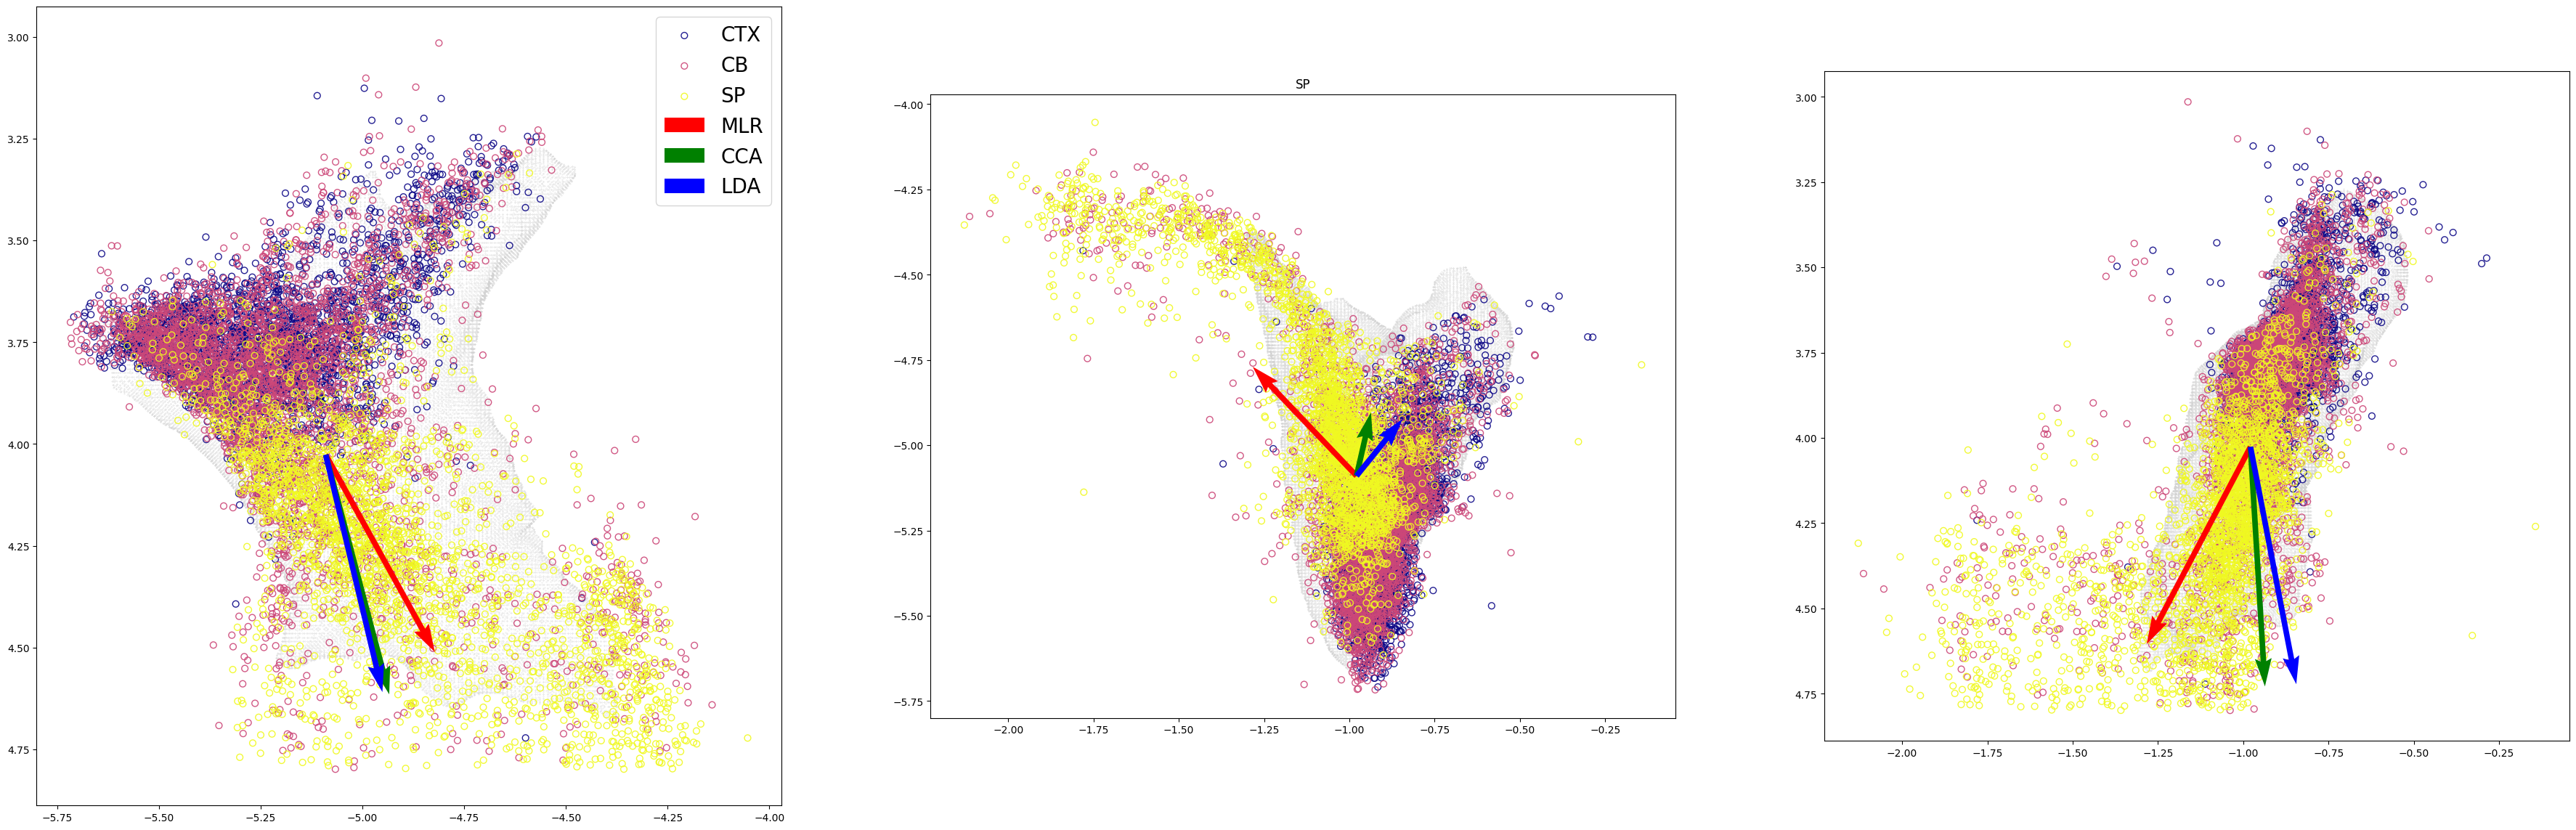

In [ ]:
fig = plt.figure(figsize=(45, 15))
gs = fig.add_gridspec(1, 3)
from matplotlib.cm import plasma
from matplotlib.colors import to_hex

category_order = ['CTX', 'CB', 'SP']
category_to_index = {cat: i for i, cat in enumerate(category_order)}

# Normalize indices to [0, 1] for colormap
norm_indices = [category_to_index[cat] / (len(category_order) - 1) for cat in category_order]
colors = [plasma(val) for val in norm_indices]

for plane, ax_ind in zip(planes.keys(), range(3)):
    ax = fig.add_subplot(gs[ax_ind])
    # Plot the mesh
    # Plot the units with projection targets
    ax.scatter(mesh_vertices_mm[:, planes_mesh[plane][0]], mesh_vertices_mm[:, planes_mesh[plane][1]], color='lightgray', alpha=1, s = 0.05)
    for ind, tar in enumerate(retro_ccf['injection_region'].unique()):
        mask = (retro_ccf['injection_region'] == tar) & (ccf_neurons_mm[:, dv_mesh] <= 4.8)
        if tar == 'TH':
            continue
        sc = ax.scatter(ccf_neurons_mm[mask, planes_mesh[plane][0]], ccf_neurons_mm[mask, planes_mesh[plane][1]], color='none', alpha=0.9, s=40, edgecolor=colors[category_order.index(tar)], label=tar, linewidths=1)
        ax.set_aspect(aspect='equal')
        if planes[plane][1] == dv:
            ax.invert_yaxis()
        if plane == 'hor':
            ax.set_title(tar)
    if planes[plane][1] == dv:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], -primary_axis_vector_MLR[planes_mesh[plane][1]],scale=3, color='red', label='MLR')
    else:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_MLR[planes_mesh[plane][0]], primary_axis_vector_MLR[planes_mesh[plane][1]],scale=3, color='red', label='MLR')
    # ax.set_title(plane)
    if planes[plane][1] == dv:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_cca[planes_mesh[plane][0]], -primary_axis_vector_cca[planes_mesh[plane][1]],scale=3, color='green', label='CCA')
    else:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_cca[planes_mesh[plane][0]], primary_axis_vector_cca[planes_mesh[plane][1]],scale=3, color='green', label='CCA')
    
    if planes[plane][1] == dv:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_LDA[planes_mesh[plane][0]], -primary_axis_vector_LDA[planes_mesh[plane][1]],scale=3, color='blue', label='LDA')
    else:
        ax.quiver(ccf_center[planes_mesh[plane][0]], ccf_center[planes_mesh[plane][1]], primary_axis_vector_LDA[planes_mesh[plane][0]], primary_axis_vector_LDA[planes_mesh[plane][1]],scale=3, color='blue', label='LDA')

    if plane == 'sag':
        ax.legend(fontsize=20, loc='upper right')
    

    